# Czech Real Estate Price Prediction

This notebook builds price-prediction model for apartments listed on sreality.cz across the Czech Republic. The dataset contains more than 17,000 real listings with location, size, condition, distance etc. features.

Seven "models" are compared: two naive baselines (a location-only one and a size-aware one), Linear Regression (raw and log-target), a Decision Tree, a Random Forest and Gradient Boosting. Every cleaning and feature-engineering decision below is backed by evidence from the data itself rather than assumed conventions. The goal is finding what actually drives price in this market.

**Notes:**
1. The train/test split is spatially grouped and de-duplicated before modeling, rather than checking for leakage afterward as a side diagnostic.
2. The naive baseline includes a size-aware version (region price/m2 x area), since an area-blind baseline was too easy to beat.
3. Decision Tree, Random Forest and Gradient Boosting are tuned via grouped cross-validated search rather than fixed by hand and every CV score is grouped by `grid_id`.
4. The headline metric is a repeated spatial evaluation, not a single train/test split.

## 1. Setup & Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import (
    train_test_split, cross_val_score, GroupShuffleSplit, GroupKFold,
    GridSearchCV, RandomizedSearchCV,
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import geopandas as gpd
import matplotlib.ticker as mticker
import os

# DELETE columns containing sensitive information (personal identifiers like phone numbers) before even processing the data.

df_raw = pd.read_csv('images_and_data/sreality_master.csv')
print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

Dataset shape: (19744, 32)


,estate_id,title,locality,region,latitude,longitude,price_czk,price_per_m2,area_m2,category,...,vlastnictvi,energ_stitek,anuita,dist_vecerka_m,dist_obchod_m,dist_tram_m,dist_metro_m,dist_bus_mhd_m,url,scraped_at
0,743747660,Prodej bytu 3+1 59 m²,Přerov - Přerov I-Město,Olomoucký kraj,49.453266,17.462451,3490000.0,59153,59,3+1,...,Osobní,G - Mimořádně nehospodárná,NaN,134.0,520.0,NaN,NaN,216.0,https://www.sreality.cz/detail/prodej/byt/3+1/...,2026-07-27T23:02:20.986901+00:00
1,3831754828,Prodej bytu 2+1 54 m²,"Uherský Ostroh, Uherské Hradiště",Zlínský kraj,48.983461,17.385952,3200000.0,59259,54,2+1,...,Osobní,G - Mimořádně nehospodárná,NaN,246.0,3556.0,NaN,NaN,281.0,https://www.sreality.cz/detail/prodej/byt/2+1/...,2026-07-27T23:02:20.986901+00:00
2,830533708,Prodej bytu 1+1 36 m²,"Havířov - Město, Karviná",Moravskoslezský kraj,49.782614,18.438353,1899000.0,52750,36,1+1,...,Družstevní,G - Mimořádně nehospodárná,NaN,396.0,492.0,NaN,NaN,65.0,https://www.sreality.cz/detail/prodej/byt/1+1/...,2026-07-27T23:02:20.986901+00:00
3,3337257036,Prodej bytu 2+1 58 m²,"Planá, Tachov",Plzeňský kraj,49.862835,12.741706,2800000.0,48276,58,2+1,...,Osobní,G - Mimořádně nehospodárná,NaN,202.0,NaN,NaN,NaN,438.0,https://www.sreality.cz/detail/prodej/byt/2+1/...,2026-07-27T23:02:20.986901+00:00
4,3350261836,Prodej bytu 1+kk 20 m²,"Plzeň - Jižní Předměstí, Plzeň-město",Plzeňský kraj,49.723533,13.374492,3250000.0,162500,20,1+kk,...,Osobní,C - Úsporná,NaN,313.0,90.0,614.0,NaN,60.0,https://www.sreality.cz/detail/prodej/byt/1+kk...,2026-07-27T23:02:20.986901+00:00


## 2. Data cleaning

In [2]:
# split columns Stavba and locality into multiple columns and clean them up
stavba_parts = df_raw['stavba'].str.split(',', expand=True)
loc_parts = df_raw['locality'].str.split(',', n=1, expand=True)

df_raw = df_raw.assign(
    # stavba
    construction = stavba_parts[0].str.strip(),
    condition    = stavba_parts[1].str.strip(),
    floor        = pd.to_numeric(stavba_parts[2].str.extract(r'(\d+)')[0], errors='coerce'),
    # locality
    city     = loc_parts[0].str.split(' - ').str[0],
    district = loc_parts[0].str.split(' - ').str[1].fillna(loc_parts[1])
)

# Praha, use second part of string as district, e.g. Praha 1, Praha 2, etc.
df_raw.loc[df_raw['city'] == 'Praha', 'district'] = loc_parts[1]

# single-value locality, district = city
df_raw['district'] = df_raw['district'].fillna(df_raw['city'])


#clean topeni column. Priority order: Zdroj vytápění - take this if exists, else Topení:, else Otopná tělesa:
df_raw['heating'] = (
    df_raw['topeni']
    .str.extract(r'Zdroj vytápění:\s*([^;]+)')[0]
    .fillna(df_raw['topeni'].str.extract(r'Topení:\s*([^;]+)')[0])
    .fillna(df_raw['topeni'].str.extract(r'Otopná tělesa:\s*([^;]+)')[0])
    .str.strip()
)

df_raw = df_raw.drop(columns=[
    'stavba','locality','estate_id','title', 'historie',
    'premise','seller', 'price_per_m2', 'scraped_at', 'studna', 'anuita',
    'prislusenstvi','infrastruktura', 'topeni', 'is_new', 'telekomunikace', 'has_video', 'has_3d'
])

In [3]:
cat = df_raw['category']

# amount of rooms (numeric)
df_raw['rooms'] = pd.to_numeric(cat.str.extract(r'(\d+)')[0], errors='coerce')

# kitchen (numeric 0 (kk) or 1)
df_raw['kitchen'] = (cat.str.extract(r'\+(kk|1)')[0].map({'kk': 0, '1': 1}))

# "a více" > kitchen = 1
df_raw.loc[cat.str.contains('a více', na=False), 'kitchen'] = 1

# "Atypický" listings are dropped outright rather than kept with an imputed rooms_num/kitchen_num and a flag.
n_before = len(df_raw)
df_raw = df_raw.loc[~cat.eq('Atypický')].copy()
cat = cat.loc[df_raw.index]
print(f"Dropped {n_before - len(df_raw)} 'Atypický' listings (no meaningful room/kitchen count)")

# drop original column
df_raw = df_raw.drop(columns='category')


Dropped 128 'Atypický' listings (no meaningful room/kitchen count)


In [4]:
energy_map = {
    'A': 7,
    'B': 6,
    'C': 5,
    'D': 4,
    'E': 3,
    'F': 2,
    'G': 1
}

df_raw['energ_stitek'] = (
    df_raw['energ_stitek']
    .fillna('')
    .str.strip()
    .str.upper()
    .str.extract(r'^([A-G])')[0]
    .map(energy_map)
)

df_raw['vlastnictvi'] = (
    df_raw['vlastnictvi']
    .map({
        'Osobní': 1,
        'Družstevní': 2
    })
    .fillna(0)
    .astype(int)
)

In [5]:
condition_map = {
    'Špatný': 1,
    'Před rekonstrukcí': 2,
    'Projekt': 3,
    'V rekonstrukci': 4,
    'Ve výstavbě': 5,
    'Dobrý': 6,
    'Velmi dobrý': 7,
    'Po rekonstrukci': 8,
    'Novostavba': 9
}

df_raw['condition'] = df_raw['condition'].map(condition_map)

# Missing energ_stitek/condition are dropped
n_before = len(df_raw)
df_raw = df_raw.dropna(subset=['energ_stitek', 'condition']).copy()
print(f"Dropped {n_before - len(df_raw)} rows missing energ_stitek and/or condition")

print(f'Dataset shape: {df_raw.shape}')
df_raw.head()


Dropped 2465 rows missing energ_stitek and/or condition
Dataset shape: (17151, 21)


,region,latitude,longitude,price_czk,area_m2,vlastnictvi,energ_stitek,dist_vecerka_m,dist_obchod_m,dist_tram_m,...,dist_bus_mhd_m,url,construction,condition,floor,city,district,heating,rooms,kitchen
0,Olomoucký kraj,49.453266,17.462451,3490000.0,59,1,1.0,134.0,520.0,NaN,...,216.0,https://www.sreality.cz/detail/prodej/byt/3+1/...,Panelová,7.0,4.0,Přerov,Přerov I-Město,Ústřední dálkové,3.0,1.0
1,Zlínský kraj,48.983461,17.385952,3200000.0,54,1,1.0,246.0,3556.0,NaN,...,281.0,https://www.sreality.cz/detail/prodej/byt/2+1/...,Cihlová,7.0,3.0,Uherský Ostroh,Uherské Hradiště,NaN,2.0,1.0
2,Moravskoslezský kraj,49.782614,18.438353,1899000.0,36,2,1.0,396.0,492.0,NaN,...,65.0,https://www.sreality.cz/detail/prodej/byt/1+1/...,Panelová,8.0,4.0,Havířov,Město,Centrální dálkové,1.0,1.0
3,Plzeňský kraj,49.862835,12.741706,2800000.0,58,1,1.0,202.0,NaN,NaN,...,438.0,https://www.sreality.cz/detail/prodej/byt/2+1/...,Panelová,6.0,4.0,Planá,Tachov,NaN,2.0,1.0
4,Plzeňský kraj,49.723533,13.374492,3250000.0,20,1,5.0,313.0,90.0,614.0,...,60.0,https://www.sreality.cz/detail/prodej/byt/1+kk...,Panelová,8.0,1.0,Plzeň,Jižní Předměstí,Ústřední dálkové,1.0,0.0


## 3. Exploratory Data Analysis & Data Cleaning

For `dist_tram_m` and `dist_metro_m`, most Czech towns simply have no tram or metro line at all. So this is not random missingness, it reflects a genuine absence of infrastructure. Decision: drop columns.

In [6]:
# Check and remove zero-price records
df_clean = df_raw[df_raw['price_czk'] > 0].copy()
print(f'Removed {len(df_raw) - len(df_clean)} zero-price records')
print(f'Cleaned dataset shape: {df_clean.shape}')

Removed 0 zero-price records
Cleaned dataset shape: (17151, 21)


### 3.1. Price distribution

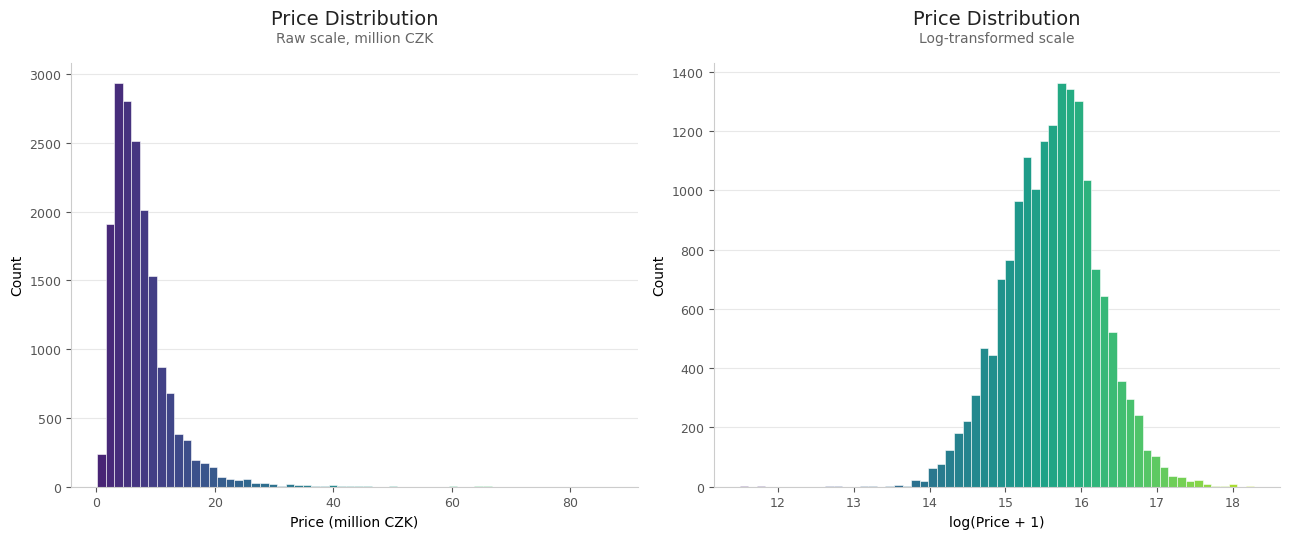

count       17151.0
mean      7393416.0
std       5277635.0
min         98000.0
25%       4038501.0
50%       6250000.0
75%       9000000.0
max      87000000.0
Name: price_czk, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

#Raw price distribution
n, bins, patches = axes[0].hist(df_clean['price_czk'] / 1e6, bins=60, edgecolor='white', linewidth=0.4)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
norm = (bin_centers - bin_centers.min()) / (bin_centers.max() - bin_centers.min())
for patch, val in zip(patches, norm):
    patch.set_facecolor(plt.cm.viridis(val * 0.8 + 0.1))

axes[0].set_title('Price Distribution', fontsize=14, loc='center', color='#222', pad=28)
axes[0].text(0.5, 1.05, 'Raw scale, million CZK', transform=axes[0].transAxes, fontsize=10, color='#666', ha='center')
axes[0].set_xlabel('Price (million CZK)')
axes[0].set_ylabel('Count')

#Log price distribution
n2, bins2, patches2 = axes[1].hist(np.log1p(df_clean['price_czk']), bins=60, edgecolor='white', linewidth=0.4)
bin_centers2 = 0.5 * (bins2[:-1] + bins2[1:])
norm2 = (bin_centers2 - bin_centers2.min()) / (bin_centers2.max() - bin_centers2.min())
for patch, val in zip(patches2, norm2): patch.set_facecolor(plt.cm.viridis(val * 0.8 + 0.1))

axes[1].set_title('Price Distribution', fontsize=14, loc='center', color='#222', pad=28)
axes[1].text(0.5, 1.05, 'Log-transformed scale', transform=axes[1].transAxes, fontsize=10, color='#666', ha='center')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

#Shared cleanup
for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(colors='#555555', labelsize=9)
    ax.grid(axis='y', color='#e8e8e8', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(df_clean['price_czk'].describe().round(0))

### 3.2. Price vs. area and correlation with numeric features

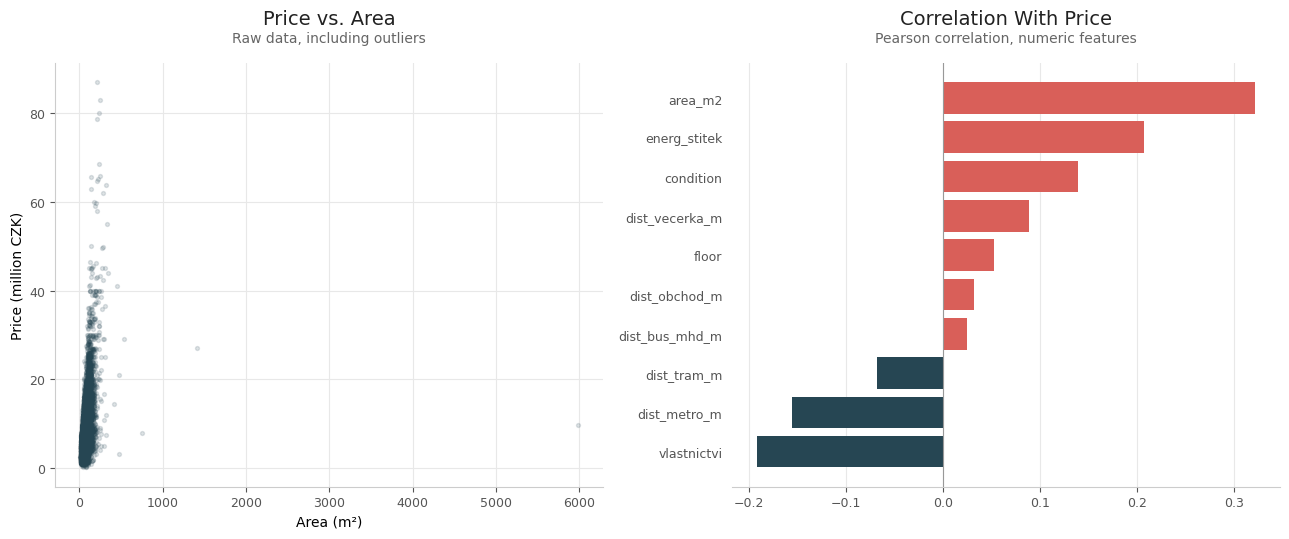

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Price vs. area (outliers included!!!)
axes[0].scatter(df_clean['area_m2'], df_clean['price_czk'] / 1e6, alpha=0.15, s=8, color='#264653')
axes[0].set_xlabel('Area (m²)')
axes[0].set_ylabel('Price (million CZK)')
axes[0].set_title('Price vs. Area', fontsize=14, loc='center', color='#222', pad=28)
axes[0].text(0.5, 1.05, 'Raw data, including outliers', transform=axes[0].transAxes, fontsize=10, color='#666', ha='center')

#Correlation with price
numeric_cols = ['price_czk', 'area_m2', 'floor', 'condition',
                'energ_stitek', 'vlastnictvi', 'dist_vecerka_m', 'dist_obchod_m',
                'dist_tram_m', 'dist_metro_m', 'dist_bus_mhd_m']
corr = df_clean[numeric_cols].corr()[['price_czk']].drop('price_czk').sort_values('price_czk')
colors = ['#D95F59' if v >= 0 else '#264653' for v in corr['price_czk']]

axes[1].barh(corr.index, corr['price_czk'], color=colors)
axes[1].axvline(0, color='#999', linewidth=0.8)
axes[1].set_title('Correlation With Price', fontsize=14, loc='center', color='#222', pad=28)
axes[1].text(0.5, 1.05, 'Pearson correlation, numeric features', transform=axes[1].transAxes, fontsize=10, color='#666', ha='center')

#Shared cleanup
for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(colors='#555555', labelsize=9)

axes[0].grid(color='#e8e8e8', linewidth=0.8, zorder=0)
axes[0].set_axisbelow(True)
axes[1].grid(axis='x', color='#e8e8e8', linewidth=0.8, zorder=0)
axes[1].set_axisbelow(True)
axes[1].tick_params(left=False)
axes[1].spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

A few things stand out already: `area_m2` is clearly the strongest raw correlate, `dist_metro_m`/`dist_tram_m` correlate *negatively* with price (closer to transit > higher price and being missing here often means being outside Prague/Brno entirely, which is itself informative). `dist_metro_m`/`dist_tram_m` will be excluded from model testing.

In [9]:
for c in ['region', 'construction']:
    print(f'--- {c} ({df_clean[c].nunique()} unique) ---')
    print(df_clean[c].value_counts().head(8))
    print()

--- region (14 unique) ---
region
Hlavní město Praha      4762
Jihomoravský kraj       1956
Středočeský kraj        1918
Moravskoslezský kraj    1320
Ústecký kraj            1153
Jihočeský kraj           926
Karlovarský kraj         821
Plzeňský kraj            795
Name: count, dtype: int64

--- construction (8 unique) ---
construction
Cihlová        9337
Panelová       4319
Smíšená        2534
Skeletová       801
Dřevostavba      82
Montovaná        38
Kamenná          38
Modulární         2
Name: count, dtype: int64



In [10]:
for c in ['rooms','kitchen', 'vlastnictvi']:
    print(f',- {c} ({df_clean[c].nunique()} unique) ---')
    print(df_clean[c].value_counts().head(8))
    print()

,- rooms (6 unique) ---
rooms
2.0    6258
3.0    6232
1.0    2500
4.0    1860
5.0     248
6.0      53
Name: count, dtype: int64

,- kitchen (2 unique) ---
kitchen
0.0    10572
1.0     6579
Name: count, dtype: int64

,- vlastnictvi (3 unique) ---
vlastnictvi
1    15504
2     1617
0       30
Name: count, dtype: int64



In [11]:
for c in ['energ_stitek', 'condition']:
    print(f'--- {c} ({df_clean[c].nunique()} unique) ---')
    print(df_clean[c].value_counts().head(8))
    print()

--- energ_stitek (7 unique) ---
energ_stitek
1.0    5750
6.0    4809
5.0    2888
4.0    1587
7.0    1265
3.0     576
2.0     276
Name: count, dtype: int64

--- condition (9 unique) ---
condition
7.0    5649
9.0    3448
6.0    3064
8.0    2070
5.0    1759
2.0     667
3.0     435
4.0      50
Name: count, dtype: int64



In [12]:
# Making copy of df_clean


df = df_clean.copy()
df['price_per_m2'] = df['price_czk'] / df['area_m2']

print(df['price_per_m2'].describe().round(0))
print()
print('Lowest price/m² listings (candidates for data errors):')
print(df.nsmallest(10, 'price_per_m2')[['price_czk', 'area_m2', 'price_per_m2', 'city']])

count     17151.0
mean     110912.0
std       56130.0
min        1195.0
25%       67558.0
50%      100343.0
75%      147963.0
max      480000.0
Name: price_per_m2, dtype: float64

Lowest price/m² listings (candidates for data errors):
       price_czk  area_m2  price_per_m2            city
13460    98000.0       82   1195.121951       Poděbrady
4124    100000.0       77   1298.701299           Tábor
13998  9689000.0     5989   1617.799299  Mladá Boleslav
2061    134500.0       40   3362.500000        Litvínov
3911    339000.0       75   4520.000000         Písečná
4025    588800.0      100   5888.000000         Písečná
1791   3200000.0      474   6751.054852          Kladno
371     990000.0      135   7333.333333      Velká Kraš
16853   690000.0       85   8117.647059       Klučenice
3674    880000.0      101   8712.871287   Horní Slavkov


Even in the cheapest Czech regions, real apartment prices run well above 10,000 CZK/m² (region medians confirm this). The listings above, priced under a few thousand CZK/m², are not genuine bargains, they're data entry errors e.g. a 5,989 m² 'apartment" for 5.7M CZK (~950 CZK/m²), or a 70 m² flat listed at 57,990 CZK total (~830 CZK/m²), both off by roughly two orders of magnitude from anywhere in this market. These are filtered out in the next cell.

In [13]:
print('Highest price/m² listings:')
print(df.nlargest(10, 'price_per_m2')[['price_czk', 'area_m2', 'price_per_m2', 'city', 'region', 'district']])

Highest price/m² listings:
        price_czk  area_m2   price_per_m2   city              region  district
16003  24000000.0       50  480000.000000  Praha  Hlavní město Praha   Praha 4
16617  63000000.0      134  470149.253731  Praha  Hlavní město Praha   Praha 4
16620  65541850.0      143  458334.615385  Praha  Hlavní město Praha   Praha 7
14338  13024000.0       29  449103.448276  Praha  Hlavní město Praha   Praha 7
17484  87000000.0      212  410377.358491  Praha  Hlavní město Praha   Praha 1
18732  19874000.0       51  389686.274510  Praha  Hlavní město Praha   Praha 8
16553  45000000.0      120  375000.000000  Praha  Hlavní město Praha   Praha 1
16533  41000000.0      110  372727.272727  Praha  Hlavní město Praha   Praha 3
16585  46500000.0      125  372000.000000  Praha  Hlavní město Praha   Praha 2
16619  78771500.0      215  366379.069767  Praha  Hlavní město Praha   Praha 2


In [14]:
# Checking where the price/m2 > 300,000 CZK tail is actually located before deciding whether to filter it out.
extreme_tail = df[df['price_per_m2'] > 300_000]
print(f"{len(extreme_tail)} listings above 300,000 CZK/m2 "
      f"({len(extreme_tail) / len(df) * 100:.2f}% of data)")
print()
print('Region breakdown:')
print(extreme_tail['region'].value_counts())
print()
print('Top localities:')
print(extreme_tail['city'].value_counts().head(5))


73 listings above 300,000 CZK/m2 (0.43% of data)

Region breakdown:
region
Hlavní město Praha      71
Karlovarský kraj         1
Královéhradecký kraj     1
Name: count, dtype: int64

Top localities:
city
Praha              71
Karlovy Vary        1
Špindlerův Mlýn     1
Name: count, dtype: int64


**Verdict:** the price/m² tail above ~300k CZK is not noise, it is overwhelmingly concentrated in Prague's most expensive districts (Vinohrady, Nové Město/Praha 1, Holešovice, Malá Strana), which is exactly where those prices are expected. No additional upper-bound filter is applied here: doing so on a hunch would have silently deleted ~75 genuine luxury listings, real signal, not errors. The only outlier that *was* a genuine data-entry error (a 5,989 m² "3+kk" at 1,618 CZK/m²) is already caught by the existing `price_per_m2 >= 10,000` floor below.

In [15]:
before = len(df)
df = df[df['price_per_m2'] >= 10000].copy()
print(f'Removed {before - len(df)} rows with implausible price/m² (< 10,000 CZK/m2, likely data-entry errors)')
print(f'Remaining: {len(df)} rows')

Removed 12 rows with implausible price/m² (< 10,000 CZK/m2, likely data-entry errors)
Remaining: 17139 rows


In [16]:
print('Suspiciously high floor values:')
print(df[df['floor'] > 25][['floor', 'city', 'area_m2']])

before = len(df)
df = df[~(df['floor'] > 25)].copy()
print(f'\nDropped {before - len(df)} rows with floor > 25 (no residential building in this '
      f'dataset legitimately has 368 floors)')
print(f'Remaining: {len(df)} rows')

Suspiciously high floor values:
      floor               city  area_m2
470    26.0  Lipno nad Vltavou       26
1746  368.0             Jirkov       68
3824  156.0            Jeseník       56

Dropped 3 rows with floor > 25 (no residential building in this dataset legitimately has 368 floors)
Remaining: 17136 rows


In [17]:
# saved cleaned dataset to csv

os.makedirs('images_and_data', exist_ok=True)
df.to_csv('images_and_data/cz_prices_cleaned.csv', index=False, encoding='utf-8-sig')
print('Saved to images_and_data/cz_prices_cleaned.csv')

print('=== Summary Statistics ===')
df.describe().round(2)

Saved to images_and_data/cz_prices_cleaned.csv
=== Summary Statistics ===


,latitude,longitude,price_czk,area_m2,vlastnictvi,energ_stitek,dist_vecerka_m,dist_obchod_m,dist_tram_m,dist_metro_m,dist_bus_mhd_m,condition,floor,rooms,kitchen,price_per_m2
count,17136.00,17136.00,17136.00,17136.00,17136.00,17136.00,17113.00,14243.00,7822.00,4660.00,17136.00,17136.00,17136.00,17136.00,17136.00,17136.00
mean,49.89,15.18,7398301.37,68.56,1.09,3.88,419.63,1144.68,874.30,1322.16,196.69,6.83,3.15,2.49,0.38,110993.46
std,0.49,1.50,5276891.71,32.18,0.30,2.25,501.49,965.01,1110.49,1205.67,170.83,1.70,2.22,0.94,0.49,56080.93
min,48.60,12.17,350000.00,10.00,0.00,1.00,0.00,0.00,5.00,13.00,1.00,1.00,0.00,1.00,0.00,10000.00
25%,49.59,14.35,4054140.00,50.00,1.00,1.00,143.00,506.00,169.00,427.00,99.00,6.00,2.00,2.00,0.00,67647.06
50%,50.04,14.52,6252412.50,64.00,1.00,5.00,265.00,879.00,357.00,864.00,160.00,7.00,3.00,2.00,0.00,100485.84
75%,50.14,16.50,9000000.00,80.00,1.00,6.00,508.00,1428.00,1201.75,1878.00,249.00,8.00,4.00,3.00,1.00,147967.00
max,51.01,18.77,87000000.00,1407.00,2.00,7.00,5658.00,6382.00,6402.00,6211.00,2659.00,9.00,23.00,6.00,1.00,480000.00


## Geographic Price Distribution & other insights

C:\Users\andre\AppData\Local\Temp\ipykernel_20636\85369249.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.96])


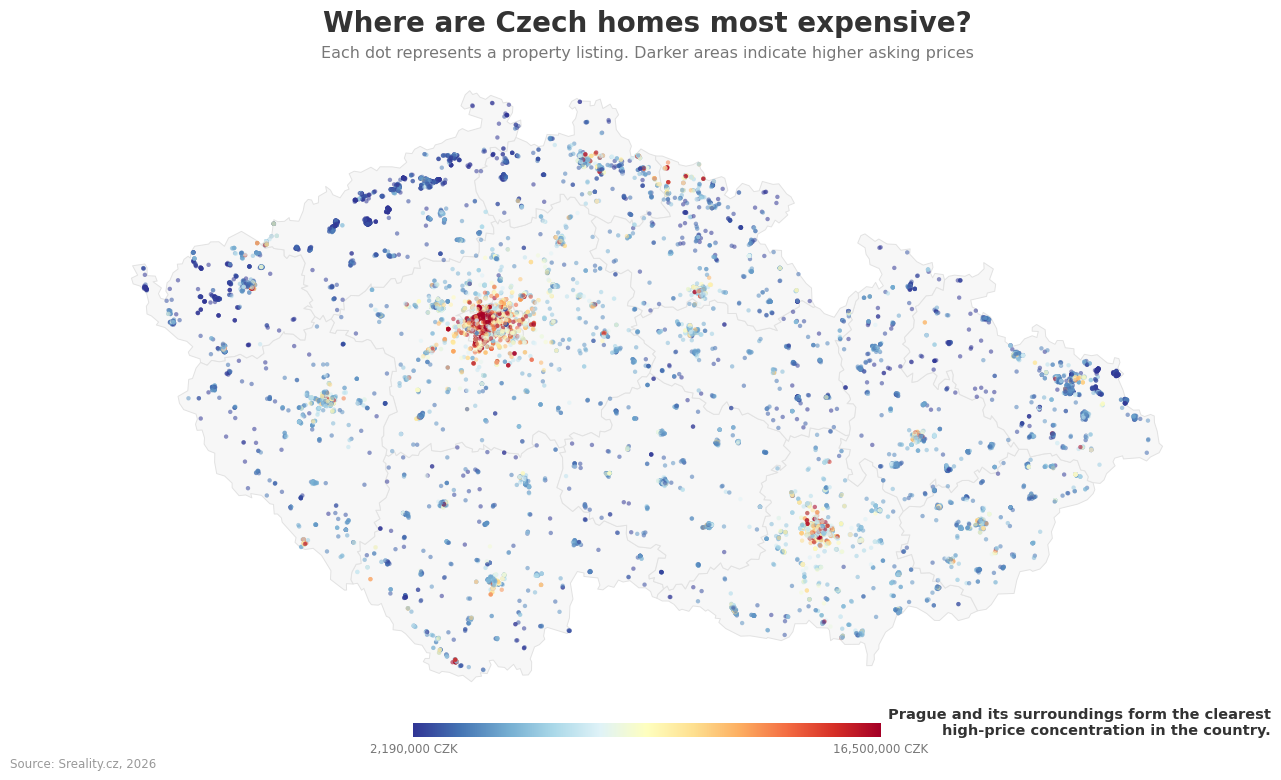

In [18]:
regions = gpd.read_file('images_and_data/czech_regions.geojson')

df_map = df[(df['price_czk'] > 0) & df['latitude'].notna() & df['longitude'].notna()].copy()

p_low, p_high = df_map['price_czk'].quantile([0.05, 0.95])
df_map['price_plot'] = df_map['price_czk'].clip(p_low, p_high)

# Colors

MAP_BACKGROUND = '#F7F7F7'
REGION_EDGE = '#E2E2E2'
POINT_LOW = '#DCE7E9'
POINT_HIGH = '#D95F59'
TEXT = '#333333'
SECONDARY = '#777777'

plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

regions.plot(ax=ax, color=MAP_BACKGROUND, edgecolor=REGION_EDGE, linewidth=0.7)

# property points

sc = ax.scatter(df_map['longitude'], df_map['latitude'], c=df_map['price_plot'], cmap='RdYlBu_r', s=10, alpha=0.55, linewidths=0, zorder=3)

minx, miny, maxx, maxy = regions.total_bounds
pad_x = (maxx - minx) * 0.035
pad_y = (maxy - miny) * 0.035
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_aspect(1 / np.cos(np.radians(49.8)))
ax.set_title('Where are Czech homes most expensive?', fontsize=20, fontweight='bold', color=TEXT, loc='center', pad=28)
subtitle = ('Each dot represents a property listing. Darker areas indicate higher asking prices')
ax.text(0.5, 1.015, subtitle, transform=ax.transAxes, fontsize=11.5, color=SECONDARY, ha='center', va='bottom')

# Remove axis
ax.set_axis_off()

gradient = np.linspace(p_low, p_high, 256).reshape(1, -1)
# Position of the gradient
cax = fig.add_axes([0.32, 0.055, 0.36, 0.018])

cax.imshow(gradient, aspect='auto', cmap='RdYlBu_r')

cax.set_xticks([0, 255])
cax.set_xticklabels([f'{p_low:,.0f} CZK', f'{p_high:,.0f} CZK'])
cax.tick_params(axis='x', length=0, labelsize=8.5, colors=SECONDARY)
cax.set_yticks([])

for spine in cax.spines.values(): spine.set_visible(False)

fig.text(
    0.98,
    0.055,
    'Prague and its surroundings form the clearest\n'
    'high-price concentration in the country.',
    ha='right',
    va='bottom',
    fontsize=10.5,
    fontweight='bold',
    color=TEXT
)

fig.text(0.01, 0.018, 'Source: Sreality.cz, 2026', fontsize=8.5, color='#999999')

# Layaut
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()

In [19]:
city         = loc_parts[0].str.split(' - ').str[0]
neighborhood = loc_parts[0].str.split(' - ').str[1]
district     = loc_parts[1].str.strip()

prague = df[df['city'] == 'Praha'].copy()
prague['neighborhood'] = neighborhood.reindex(prague.index).fillna('Neuvedeno')
print(f'Prague subset: {prague.shape}  ({len(prague)/len(df)*100:.1f}% of national data)')
print(f"Unique neighborhoods: {prague['neighborhood'].nunique()}")

Prague subset: (4762, 23)  (27.8% of national data)
Unique neighborhoods: 115


                         median        mean  count
region                                            
Hlavní město Praha    9900000.0  11746299.0   4762
Jihomoravský kraj     7100000.0   7575367.0   1956
Středočeský kraj      6679000.0   7224704.0   1918
Královéhradecký kraj  5490000.0   5932645.0    661
Plzeňský kraj         5184000.0   5586489.0    795
Jihočeský kraj        4995000.0   5784690.0    926
Liberecký kraj        4990000.0   5811319.0    713
Zlínský kraj          4950000.0   5554335.0    535
Pardubický kraj       4847500.0   5161108.0    460
Olomoucký kraj        4590000.0   5093890.0    704
Kraj Vysočina         4473009.0   4829420.0    427
Karlovarský kraj      3999999.0   4950213.0    821
Moravskoslezský kraj  3750000.0   4327802.0   1320
Ústecký kraj          2750000.0   3088125.0   1153


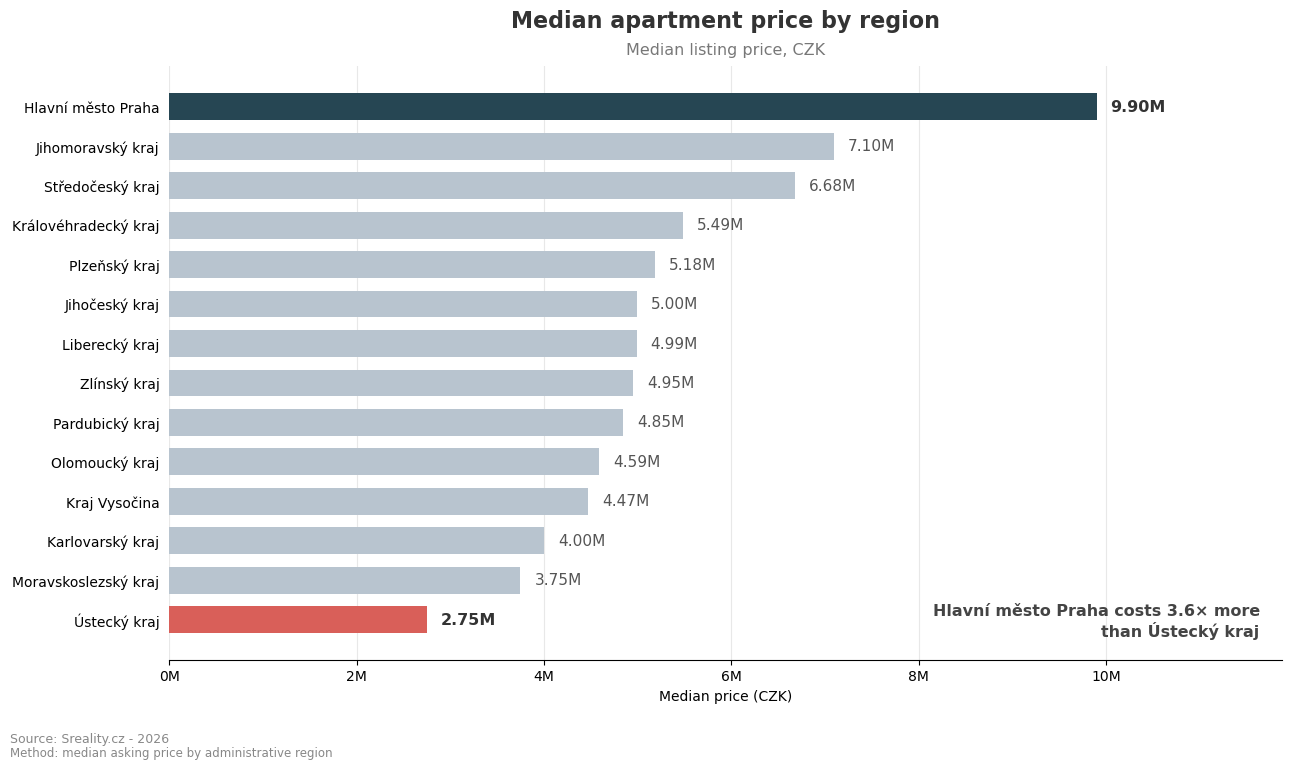

In [20]:
region_stats = df_clean.groupby('region')['price_czk'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)
print(region_stats.round(0))

data = region_stats['median'].sort_values()

top_name = data.index[-1]
bottom_name = data.index[0]
gap = data.iloc[-1] / data.iloc[0]

# Main colors (matching the budget chart's palette)
COLOR_DEFAULT = '#B8C4CF'
COLOR_TOP = '#264653'
COLOR_BOTTOM = '#D95F59'
COLOR_TEXT = '#333333'
COLOR_SECONDARY = '#777777'
COLOR_GRID = '#E8E8E8'

colors = []
for name in data.index:
    if name == top_name:
        colors.append(COLOR_TOP)
    elif name == bottom_name:
        colors.append(COLOR_BOTTOM)
    else:
        colors.append(COLOR_DEFAULT)

plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.barh(data.index, data.values, height=0.68, color=colors)

for bar, val, name in zip(bars, data.values, data.index):
    if name in (top_name, bottom_name):
        fontsize, fontweight, text_color = 11.5, 'bold', COLOR_TEXT
    else:
        fontsize, fontweight, text_color = 11, 'normal', '#555555'
    ax.text(val + data.max()*0.015, bar.get_y() + bar.get_height() / 2,
            f'{val/1e6:.2f}M', va='center', ha='left',
            fontsize=fontsize, fontweight=fontweight, color=text_color)

ax.set_axisbelow(True)
ax.grid(axis='x', color=COLOR_GRID, linewidth=0.8, linestyle='-')
ax.set_title('Median apartment price by region', fontsize=16, fontweight='bold', color=COLOR_TEXT, loc='center', pad=28)
subtitle = 'Median listing price, CZK'
ax.text(0.5, 1.015, subtitle, transform=ax.transAxes, fontsize=11.5, color=COLOR_SECONDARY, ha='center', va='bottom')

ax.set_xlabel('Median price (CZK)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, data.max() * 1.20)

takeaway = f'{top_name} costs {gap:.1f}× more\nthan {bottom_name}'
ax.text(0.98, 0.035, takeaway, transform=ax.transAxes, ha='right', va='bottom',
        fontsize=11.5, fontweight='bold', color='#444444')

fig.text(0.01, 0.025, 'Source: Sreality.cz - 2026', fontsize=9, color='#888888')
fig.text(0.01, 0.008, 'Method: median asking price by administrative region', fontsize=8.5, color='#888888')

plt.tight_layout(rect=[0, 0.055, 1, 0.96])
plt.show()

Prague's median price (~10.0M CZK) is more than **3.5x** the cheapest region, Ústecký kraj (~2.7M CZK).

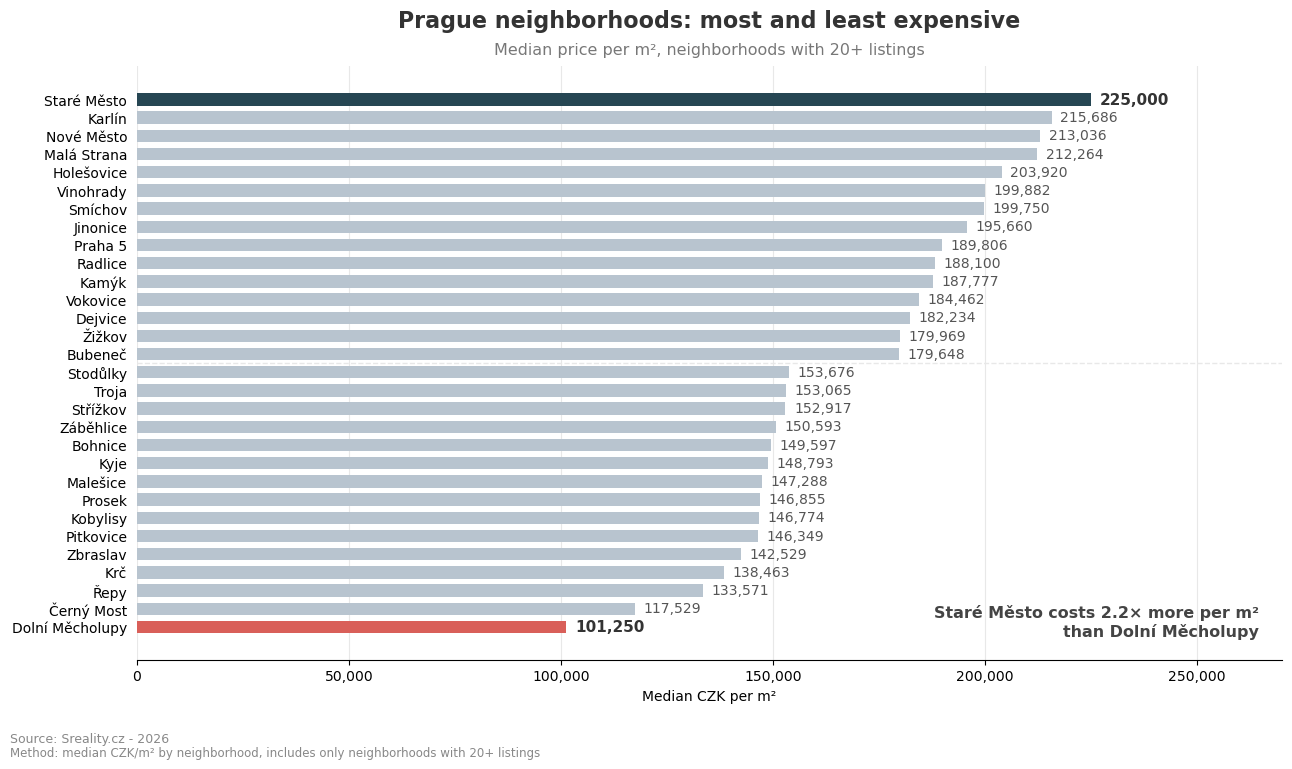

In [21]:
order = prague.groupby('neighborhood')['price_per_m2'].agg(['median', 'count'])
order = order[order['count'] >= 20].sort_values('median', ascending=False)
top15 = order.head(15)
bottom15 = order.tail(15)
combined = pd.concat([top15, bottom15])

top_name = top15.index[0]
bottom_name = bottom15.index[-1]
gap = top15['median'].iloc[0] / bottom15['median'].iloc[-1]

# Main colors
COLOR_DEFAULT = '#B8C4CF'
COLOR_TOP = '#264653'
COLOR_BOTTOM = '#D95F59'
COLOR_TEXT = '#333333'
COLOR_SECONDARY = '#777777'
COLOR_GRID = '#E8E8E8'

colors = []
for name in combined.index:
    if name == top_name:
        colors.append(COLOR_TOP)
    elif name == bottom_name:
        colors.append(COLOR_BOTTOM)
    else:
        colors.append(COLOR_DEFAULT)

plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.barh(combined.index[::-1], combined['median'].values[::-1], height=0.68, color=colors[::-1])

for bar, value, name in zip(bars, combined['median'].values[::-1], combined.index[::-1]):
    if name in (top_name, bottom_name):
        fontsize, fontweight, text_color = 11, 'bold', COLOR_TEXT
    else:
        fontsize, fontweight, text_color = 10, 'normal', '#555555'
    ax.text(
        value + 2000,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}',
        va='center', ha='left',
        fontsize=fontsize, fontweight=fontweight, color=text_color
    )

ax.axhline(14.5, color=COLOR_GRID, linewidth=1.0, linestyle='--')

ax.set_axisbelow(True)
ax.grid(axis='x', color=COLOR_GRID, linewidth=0.8, linestyle='-')
ax.set_title('Prague neighborhoods: most and least expensive', fontsize=16, fontweight='bold', color=COLOR_TEXT, loc='center', pad=28)
subtitle = 'Median price per m², neighborhoods with 20+ listings'
ax.text(0.5, 1.015, subtitle, transform=ax.transAxes, fontsize=11.5, color=COLOR_SECONDARY, ha='center', va='bottom')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Median CZK per m²')
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, combined['median'].max() * 1.20)

takeaway = f'{top_name} costs {gap:.1f}× more per m²\nthan {bottom_name}'
ax.text(0.98, 0.035, takeaway, transform=ax.transAxes, ha='right', va='bottom', fontsize=11.5, fontweight='bold', color='#444444')

fig.text(0.01, 0.025, 'Source: Sreality.cz - 2026', fontsize=9, color='#888888')
fig.text(0.01, 0.008, 'Method: median CZK/m² by neighborhood, includes only neighborhoods with 20+ listings', fontsize=8.5, color='#888888')

plt.tight_layout(rect=[0, 0.055, 1, 0.96])
plt.show()

In [22]:
top10_prague = prague.nlargest(15, 'price_czk')[
    ['city', 'district', 'area_m2', 'floor', 'rooms', 'price_czk', 'url']
].copy()

top10_prague['price_czk'] = top10_prague['price_czk'].map('{:,.0f}'.format)
top10_prague['area_m2'] = top10_prague['area_m2'].map('{:.0f}'.format)

with pd.option_context('display.max_colwidth', None):
    print(top10_prague.to_string(index=False))

 city district area_m2  floor  rooms  price_czk                                                                                       url
Praha  Praha 1     212    5.0    4.0 87,000,000            https://www.sreality.cz/detail/prodej/byt/4+kk/praha-josefov-siroka/4195485004
Praha  Praha 1     231    4.0    6.0 79,990,000       https://www.sreality.cz/detail/prodej/byt/6-a-vice/praha-mala-strana-uvoz/174055500
Praha  Praha 2     215    6.0    4.0 78,771,500          https://www.sreality.cz/detail/prodej/byt/4+kk/praha-vinohrady-polska/3094642764
Praha  Praha 7     234    5.0    5.0 68,609,923      https://www.sreality.cz/detail/prodej/byt/5+kk/praha-holesovice-komunardu/1709572940
Praha  Praha 5     246    7.0    5.0 65,817,960           https://www.sreality.cz/detail/prodej/byt/5+kk/praha-smichov-siklove/2883384140
Praha  Praha 7     143    7.0    4.0 65,541,850                https://www.sreality.cz/detail/prodej/byt/4+kk/praha-holesovice-/822100812
Praha  Praha 5     227    7.0    5

4594 of 4762 Prague listings (96.5%) have a metro-distance value
(nationally this field is 72.8% missing, mostly unusable outside Prague/Brno/Ostrava)


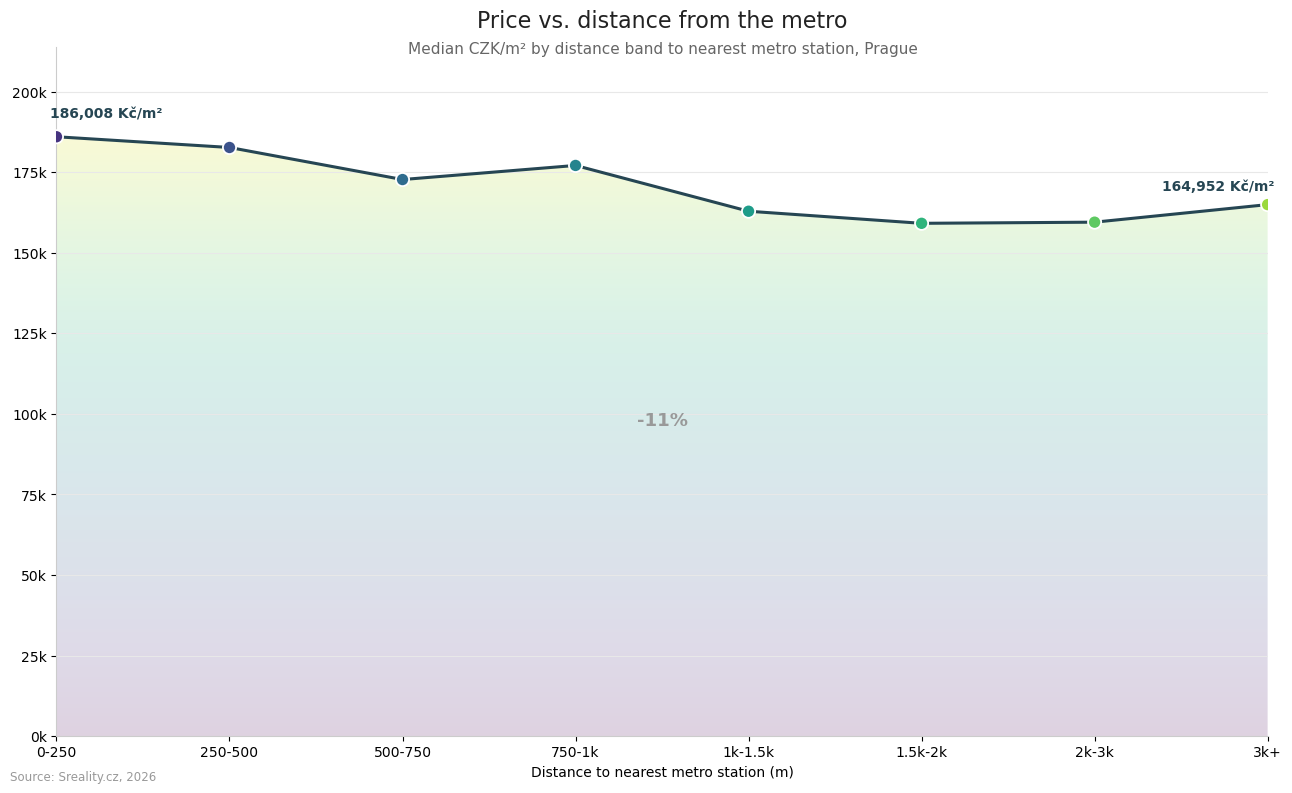

In [23]:
metro_avail = prague[prague['dist_metro_m'].notna()].copy()
print(f"{metro_avail.shape[0]} of {prague.shape[0]} Prague listings ({metro_avail.shape[0]/prague.shape[0]*100:.1f}%) have a metro-distance value")
print(f"(nationally this field is {df['dist_metro_m'].isna().mean()*100:.1f}% missing, mostly unusable outside Prague/Brno/Ostrava)")


bins = [0, 250, 500, 750, 1000, 1500, 2000, 3000, np.inf]
labels = ['0-250', '250-500', '500-750', '750-1k', '1k-1.5k', '1.5k-2k', '2k-3k', '3k+']
metro_avail['dist_bin'] = pd.cut(metro_avail['dist_metro_m'], bins=bins, labels=labels)
binned = metro_avail.groupby('dist_bin', observed=True)['price_per_m2'].median()

x = np.arange(len(binned))
y = binned.values

fig, ax = plt.subplots(figsize=(13, 8))

#Gradient fill under the curve
from matplotlib.patches import Polygon
z = np.linspace(0, 1, 256).reshape(-1, 1)
im = ax.imshow(z, aspect='auto', cmap='viridis', alpha=0.18,
               extent=[x.min(), x.max(), 0, y.max() * 1.05], origin='lower', zorder=0)
poly = Polygon(np.column_stack([np.concatenate([x, x[::-1]]),
                                 np.concatenate([y, np.zeros_like(y)])]),
                closed=True)
poly.set_transform(ax.transData)  # without this the clip path uses IdentityTransform (display coords) instead of data coords
im.set_clip_path(poly)
ax.add_patch(Polygon(np.column_stack([x, y]).tolist() + [[x[-1], 0], [x[0], 0]],
                      closed=True, facecolor='none', edgecolor='none'))

#Line + gradient-colored markers
ax.plot(x, y, color='#264653', linewidth=2.2, zorder=2)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(x)))
ax.scatter(x, y, c=colors, s=90, zorder=3, edgecolor='white', linewidth=1.3)

#Endpoint annotations
ax.annotate(f'{y[0]:,.0f} Kč/m²', (x[0], y[0]), textcoords='offset points',
            xytext=(-5, 14), fontsize=10, color='#264653', fontweight='bold', ha='left')
ax.annotate(f'{y[-1]:,.0f} Kč/m²', (x[-1], y[-1]), textcoords='offset points',
            xytext=(5, 10), fontsize=10, color='#264653', fontweight='bold', ha='right')

drop_pct = (1 - y[-1] / y[0]) * 100
ax.annotate(f'-{drop_pct:.0f}%', xy=((x[0]+x[-1])/2, (y[0]+y[-1])/2 * 0.55),
            fontsize=13, color='#999', fontweight='bold', ha='center')

ax.set_xticks(x)
ax.set_xticklabels(binned.index.astype(str))

ax.set_title('Price vs. distance from the metro', fontsize=16, loc='center', color='#222', pad=14)
ax.text(0.29, 0.99, 'Median CZK/m² by distance band to nearest metro station, Prague', transform=ax.transAxes, fontsize=11, color='#666')

ax.set_xlabel('Distance to nearest metro station (m)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.set_ylim(0, y.max() * 1.15)
fig.text(0.01, 0.018, 'Source: Sreality.cz, 2026', fontsize=8.5, color='#999999')
plt.tight_layout()
plt.show()

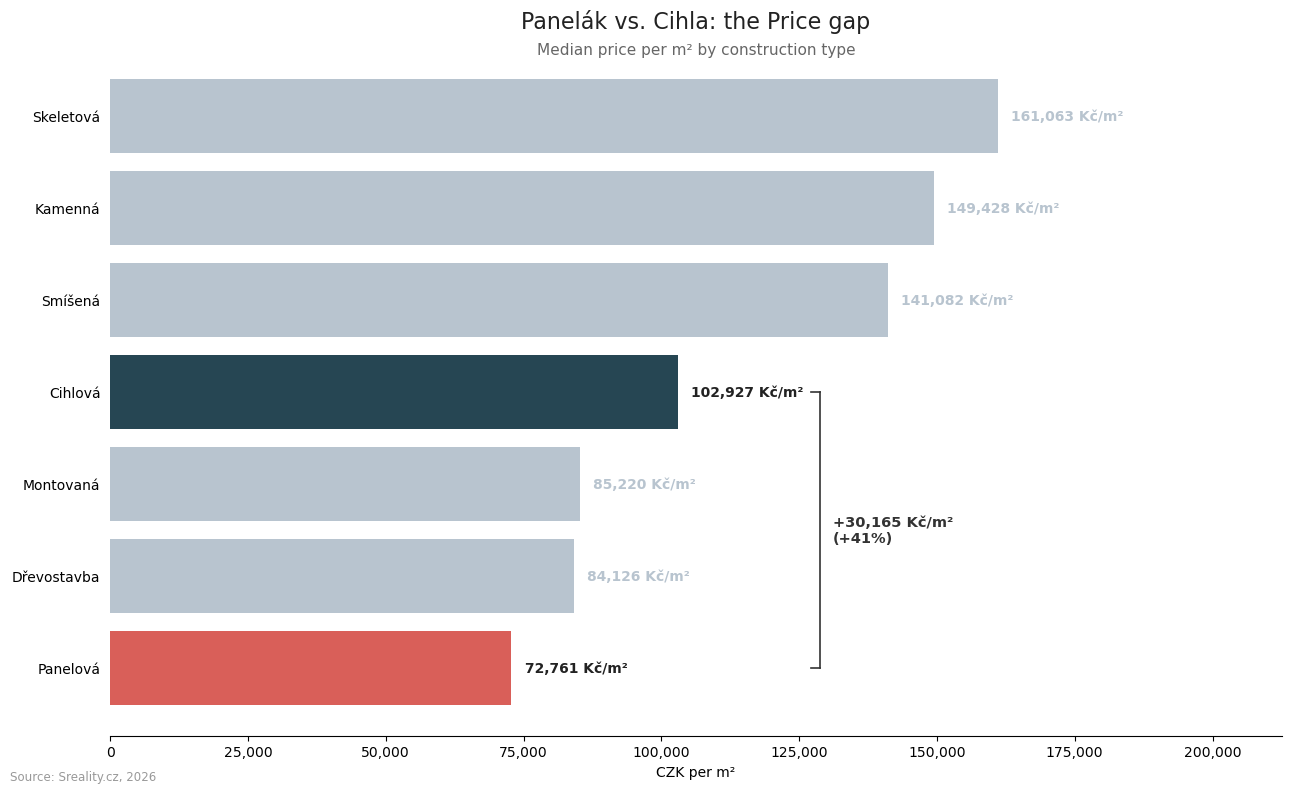

In [24]:
order = df.groupby('construction')['price_per_m2'].median().sort_values(ascending=False)
counts = df['construction'].value_counts()
order = order[counts.reindex(order.index) >= 30]

colors = ['#D95F59' if c == 'Panelová' else '#264653' if c == 'Cihlová' else '#B8C4CF' for c in order.index]

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(order.index[::-1], order.values[::-1], color=colors[::-1])

for bar, val, label in zip(bars, order.values[::-1], order.index[::-1]):
    is_highlight = label in ('Panelová', 'Cihlová')
    ax.text(val + order.max()*0.015, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f} Kč/m²', va='center', fontsize=10,
            color='#222' if is_highlight else "#B8C4CF",
            fontweight='bold' if is_highlight else 'bold')

ax.set_title('Panelák vs. Cihla: the Price gap', fontsize=16, loc='center', color='#222', pad=14)
ax.text(0.364, 0.99, 'Median price per m² by construction type', transform=ax.transAxes, fontsize=11, color='#666')

panel_val = order['Panelová']
cihla_val = order['Cihlová']
y_panel = order.index[::-1].get_loc('Panelová')
y_cihla = order.index[::-1].get_loc('Cihlová')
y_mid = (y_panel + y_cihla) / 2
x_bracket = max(panel_val, cihla_val) + order.max() * 0.16

ax.plot([x_bracket, x_bracket], [y_panel, y_cihla], color='#333', linewidth=1.2)
ax.plot([x_bracket - order.max()*0.01, x_bracket], [y_panel, y_panel], color='#333', linewidth=1.2)
ax.plot([x_bracket - order.max()*0.01, x_bracket], [y_cihla, y_cihla], color='#333', linewidth=1.2)

diff = cihla_val - panel_val
pct = diff / panel_val * 100
ax.text(x_bracket + order.max()*0.015, y_mid,
        f'+{diff:,.0f} Kč/m²\n(+{pct:.0f}%)',
        va='center', fontsize=10.5, color='#333', fontweight='bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('CZK per m²')
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, order.max() * 1.32)
fig.text(0.01, 0.018, 'Source: Sreality.cz, 2026', fontsize=8.5, color='#999999')
plt.tight_layout()
plt.show()

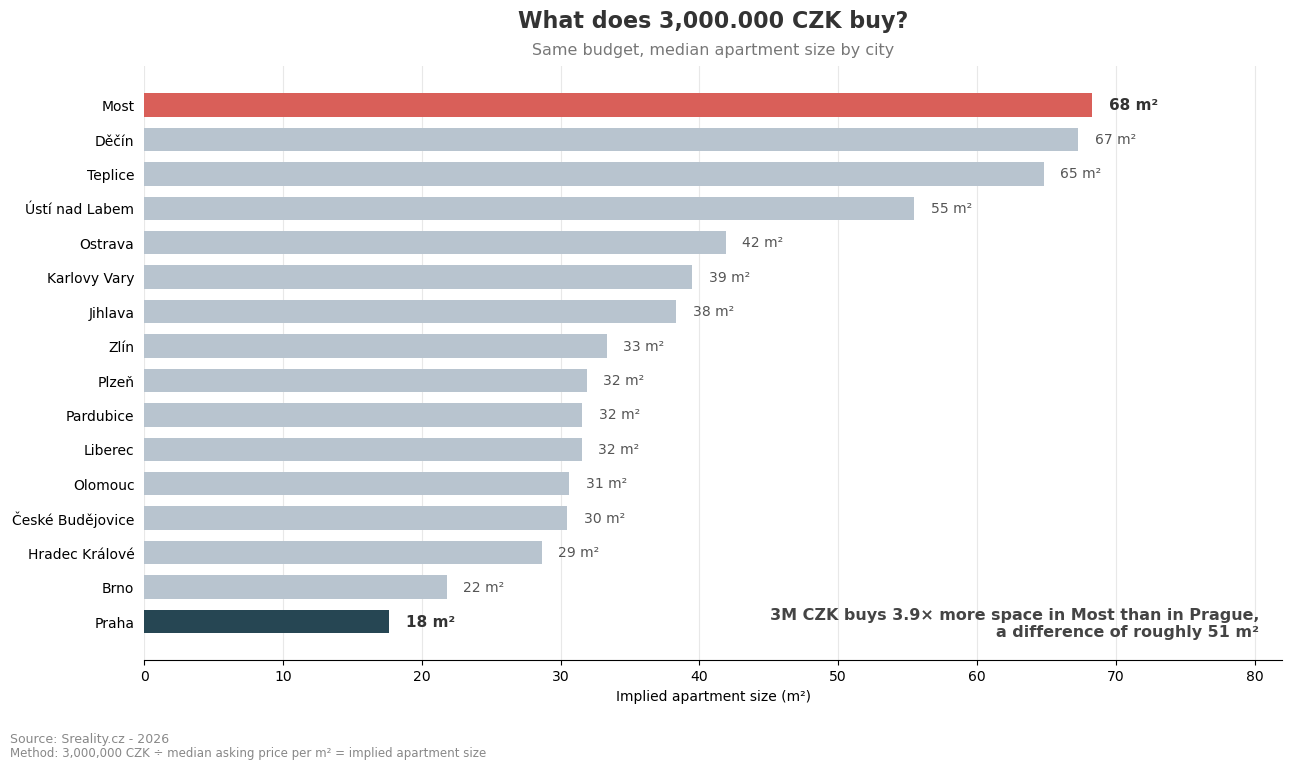

In [25]:
# What a fixed budget buys you, city by city
BUDGET = 3_000_000

budget_cities = ['Praha', 'Brno', 'Olomouc', 'Karlovy Vary', 'Ostrava','Ústí nad Labem', 'Plzeň', 'Liberec',
    'Hradec Králové', 'Pardubice', 'Zlín', 'Jihlava', 'České Budějovice', 'Teplice', 'Děčín', 'Most']


rows = []

for city in budget_cities:
    sub = df[df['city'] == city]
    median_price_m2 = sub['price_per_m2'].median() # Median price per m² in the city
    # How many m² could theoretically be bought
    area = BUDGET / median_price_m2
    rows.append({'city': city, 'area': area, 'median_price_m2': median_price_m2})

res = (pd.DataFrame(rows).dropna().sort_values('area').reset_index(drop=True))
praha_area = res.loc[res['city'] == 'Praha', 'area'].iloc[0]
most_area = res.loc[res['city'] == 'Most', 'area'].iloc[0]

# How many times more space in Most than Prague
ratio = most_area / praha_area
# Difference in square meters
difference = most_area - praha_area
# Index positions for annotations
praha_index = res.index[res['city'] == 'Praha'].tolist()[0]
most_index = res.index[res['city'] == 'Most'].tolist()[0]

# Main colors
COLOR_DEFAULT = '#B8C4CF'
COLOR_PRAHA = '#264653'
COLOR_MOST = '#D95F59'
COLOR_TEXT = '#333333'
COLOR_SECONDARY = '#777777'
COLOR_GRID = '#E8E8E8'

colors = []

for city in res['city']:    
    if city == 'Praha':
        colors.append(COLOR_PRAHA)
    elif city == 'Most':
        colors.append(COLOR_MOST)
    else:
        colors.append(COLOR_DEFAULT)

plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
bars = ax.barh(res['city'], res['area'], height=0.68, color=colors)

for bar, value, city in zip(bars, res['area'], res['city']):
    # Slightly larger / darker labels for the highlighted cities
    if city in ['Praha', 'Most']:
        fontsize = 11
        fontweight = 'bold'
        text_color = COLOR_TEXT
    else:
        fontsize = 10
        fontweight = 'normal'
        text_color = '#555555'
    ax.text(value + 1.2, bar.get_y() + bar.get_height() / 2, f'{value:.0f} m²', va='center', ha='left', fontsize=fontsize, fontweight=fontweight, color=text_color)

ax.set_axisbelow(True)
ax.grid(axis='x', color=COLOR_GRID, linewidth=0.8, linestyle='-')
ax.set_title('What does 3,000.000 CZK buy?', fontsize=16, fontweight='bold', color=COLOR_TEXT, loc='center', pad=28)
subtitle = (f'Same budget, median apartment size by city')
ax.text(0.5, 1.015, subtitle, transform=ax.transAxes, fontsize=11.5, color=COLOR_SECONDARY, ha='center', va='bottom')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Implied apartment size (m²)')
for spine in ['top', 'right', 'left']: ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, res['area'].max() * 1.20)

takeaway = (
    f'3M CZK buys {ratio:.1f}× more space in Most than in Prague,\n'
    f'a difference of roughly {difference:.0f} m²'
)

ax.text(0.98, 0.035, takeaway, transform=ax.transAxes, ha='right', va='bottom', fontsize=11.5, fontweight='bold', color='#444444')
max_area = res['area'].max()
ax.set_xlim(0, max_area * 1.20)
fig.text(0.01, 0.025, 'Source: Sreality.cz - 2026', fontsize=9, color='#888888')
fig.text(0.01, 0.008, 'Method: 3,000,000 CZK ÷ median asking price per m² = implied apartment size', fontsize=8.5, color='#888888')

plt.tight_layout(rect=[0, 0.055, 1, 0.96])
plt.show()

# How much does apartment condition matter?

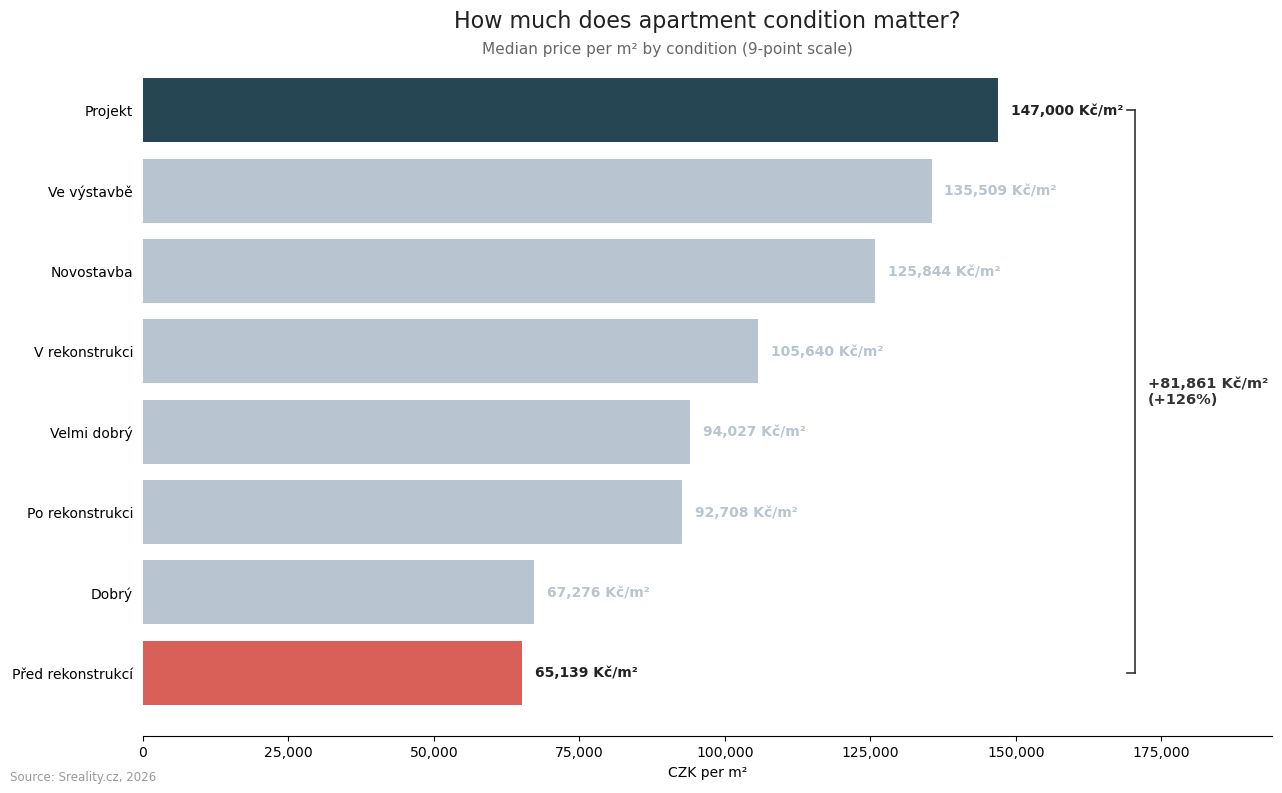

In [26]:
condition_labels = {
    1: 'Špatný', 2: 'Před rekonstrukcí', 3: 'Projekt', 4: 'V rekonstrukci',
    5: 'Ve výstavbě', 6: 'Dobrý', 7: 'Velmi dobrý', 8: 'Po rekonstrukci', 9: 'Novostavba'
}

order = df.groupby('condition')['price_per_m2'].median()
counts = df['condition'].value_counts()
order = order[counts.reindex(order.index) >= 30]
order.index = order.index.map(condition_labels)
order = order.sort_values(ascending=False)

# Highlight whichever categories actually survive the count filter, not fixed labels
best_label, worst_label = order.index[0], order.index[-1]
colors = ['#264653' if c == best_label else '#D95F59' if c == worst_label else '#B8C4CF' for c in order.index]

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(order.index[::-1], order.values[::-1], color=colors[::-1])

for bar, val, label in zip(bars, order.values[::-1], order.index[::-1]):
    is_highlight = label in (best_label, worst_label)
    ax.text(val + order.max()*0.015, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f} Kč/m²', va='center', fontsize=10,
            color='#222' if is_highlight else '#B8C4CF', fontweight='bold')

ax.set_title('How much does apartment condition matter?', fontsize=16, loc='center', color='#222', pad=14)
ax.text(0.30, 0.99, 'Median price per m² by condition (9-point scale)', transform=ax.transAxes, fontsize=11, color='#666')

best_val = order[best_label]
worst_val = order[worst_label]
y_best = order.index[::-1].get_loc(best_label)
y_worst = order.index[::-1].get_loc(worst_label)
y_mid = (y_best + y_worst) / 2
x_bracket = max(best_val, worst_val) + order.max() * 0.16

ax.plot([x_bracket, x_bracket], [y_best, y_worst], color='#333', linewidth=1.2)
ax.plot([x_bracket - order.max()*0.01, x_bracket], [y_best, y_best], color='#333', linewidth=1.2)
ax.plot([x_bracket - order.max()*0.01, x_bracket], [y_worst, y_worst], color='#333', linewidth=1.2)

diff = best_val - worst_val
pct = diff / worst_val * 100
ax.text(x_bracket + order.max()*0.015, y_mid,
        f'+{diff:,.0f} Kč/m²\n(+{pct:.0f}%)',
        va='center', fontsize=10.5, color='#333', fontweight='bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('CZK per m²')
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, order.max() * 1.32)
fig.text(0.01, 0.018, 'Source: Sreality.cz, 2026', fontsize=8.5, color='#999999')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Each transformation below is motivated by something observed in the data, not applied by default:

- **`dist_to_prague_km`**: straight-line (haversine) distance to Prague's center. Region alone is coarse (14 buckets); this gives a continuous location signal, especially useful for towns near Prague but outside its region.
- **`has_tram_access` / `has_metro_access`**: binary flags built from the *missingness* of `dist_tram_m`/`dist_metro_m`, since missing genuinely means "not available here", not "unknown", metro exists only in Prague and trams only in a handful of Czech cities, so most of the country is structurally missing both. Instead, `dist_tram_m`/`dist_metro_m` are dropped as columns entirely, keeping only the binary flags, the information that actually generalizes nationwide, without inventing a distance or gutting the sample.
- **`primary_heating`**: `heating` has 201 unique values because it's a free-form, comma-separated multi-select field (e.g. "Plynový kotel, Krb"). Taking just the first listed type cuts this to a manageable ~27 categories.
- **`rooms_num` / `kitchen_num`**: `rooms` and `kitchen` both use the literal string `"Atypický"` for the same listings. There's no honest room/kitchen count for a layout that's non-standard by definition, so these listings are dropped outright during cleaning rather than kept with an imputed value and a flag.
- **`city` / `district` are dropped**: 1,237 and 818 unique values respectively is too high-cardinality to one-hot safely and target-encoding them without careful out-of-fold handling risks leakage. `region` + `dist_to_prague_km` already give the model real geographic resolution without that risk.
- **`latitude` / `longitude` are dropped from the model features**: they are highly correlated with the engineered `dist_to_prague_km` (which is itself a function of the two) and this collinearity destabilizes the Linear Regression coefficients in particular (tree-based models are largely unaffected, since they split on one variable at a time). `region` (coarse location) + `dist_to_prague_km` (continuous location signal) together retain most of the useful geographic information without the redundancy.
- **`energ_stitek` / `condition` are kept as ordinal numeric, not one-hot categorical**: both were deliberately mapped to ordered integer scales during cleaning (energy label A>G as 7>1, condition Špatný>Novostavba as 1>9). One-hot encoding them, as an earlier version of this notebook did, would discard that ordering. Treating them as numeric preserves the ordinal structure, which matters most for the linear model. `vlastnictvi` (ownership type) has no natural order, so it stays one-hot encoded.
- **`grid_id`**: a ~2km latitude/longitude grid cell id, computed here (not just as a post-hoc diagnostic) because it's now used for two things: (1) de-duplicating near-identical listings and (2) making the train/test split itself geography-aware.
- **Near-duplicate listings are removed from the full dataset, not just from a later diagnostic.** Listings sharing identical latitude/longitude/area/price are almost certainly re-listings or duplicate scrapes of the same property, not independent observations.

In [27]:
PRAGUE_LAT, PRAGUE_LON = 50.0755, 14.4378

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['dist_to_prague_km'] = haversine_km(df['latitude'], df['longitude'], PRAGUE_LAT, PRAGUE_LON)

df['rooms_num'] = pd.to_numeric(df['rooms'], errors='coerce')
df['kitchen_num'] = pd.to_numeric(df['kitchen'], errors='coerce')

def primary_heating(x):
    return 'Neuvedeno' if pd.isna(x) else x.split(',')[0].strip()
df['primary_heating'] = df['heating'].apply(primary_heating)
print(f"primary_heating: reduced from {df['heating'].nunique()} to {df['primary_heating'].nunique()} categories")

df['has_tram_access'] = df['dist_tram_m'].notna().astype(int)
df['has_metro_access'] = df['dist_metro_m'].notna().astype(int)


print(f"Dropping dist_tram_m/dist_metro_m ({df['dist_tram_m'].isna().mean()*100:.1f}%/"
      f"{df['dist_metro_m'].isna().mean()*100:.1f}% missing) - keeping has_tram_access/has_metro_access instead.")
df = df.drop(columns=['dist_tram_m', 'dist_metro_m'])

df['construction'] = df['construction'].fillna('Neuvedeno')

# - Spatial grid cell id -
GRID_DEG = 0.02  # roughly ~1.5-2 km cells at Czech latitudes; a design choice, not a fitted parameter
df['grid_id'] = (
    (df['latitude'] // GRID_DEG).astype(int).astype(str) + '_' +
    (df['longitude'] // GRID_DEG).astype(int).astype(str)
)

# -Removed near-duplicate listings upfront, from the FULL dataset -

n_before = len(df)
df = df.loc[~df.duplicated(subset=['latitude', 'longitude', 'area_m2', 'price_czk'],
                            keep='first')].copy()
n_removed = n_before - len(df)
print(f'Removed {n_removed} near-duplicate listings ({n_removed / n_before * 100:.1f}%) '
      f'before splitting (previously only excluded from the section 8 diagnostic).')

print('\nFeature engineering complete. Final shape:', df.shape)

primary_heating: reduced from 198 to 27 categories
Dropping dist_tram_m/dist_metro_m (54.4%/72.8% missing) - keeping has_tram_access/has_metro_access instead.
Removed 363 near-duplicate listings (2.1%) before splitting (previously only excluded from the section 8 diagnostic).

Feature engineering complete. Final shape: (16773, 27)


# How much does Prague proximity cost?

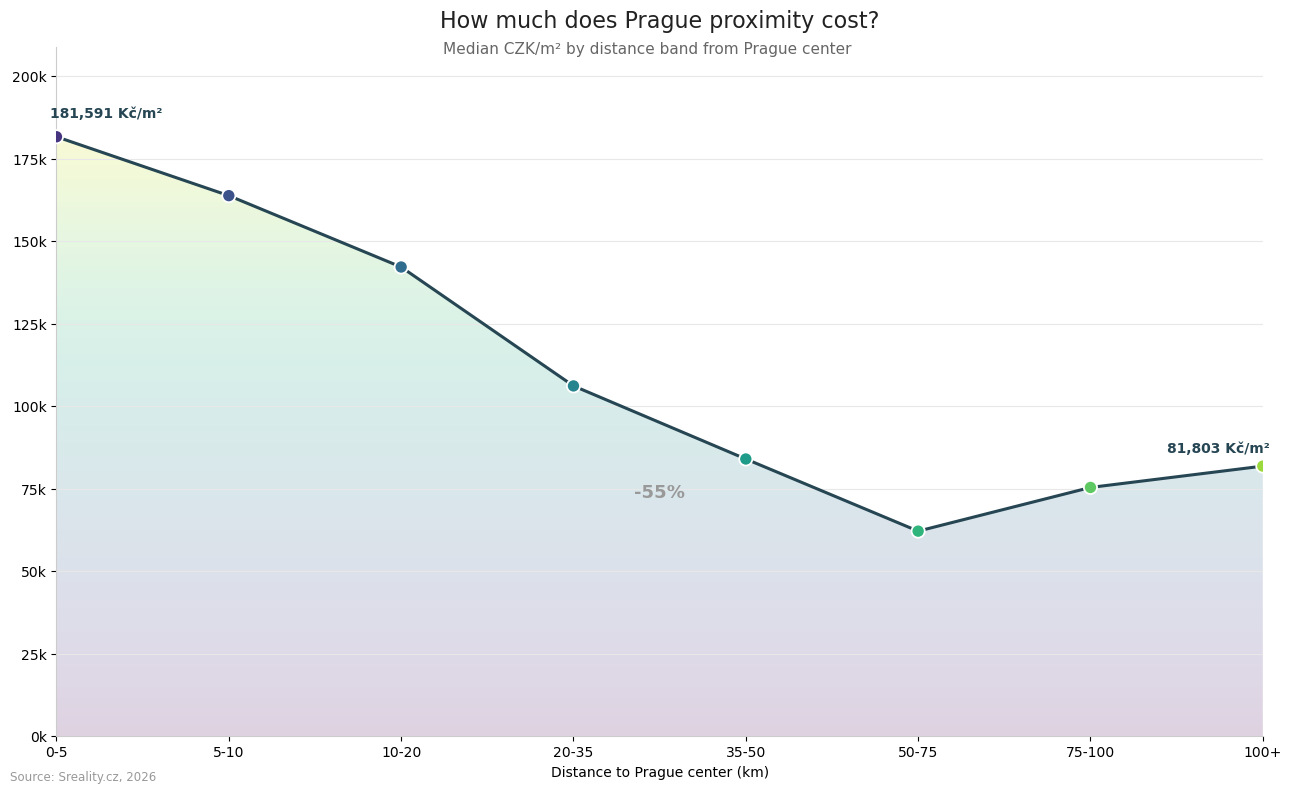

In [28]:
bins = [0, 5, 10, 20, 35, 50, 75, 100, np.inf]
labels = ['0-5', '5-10', '10-20', '20-35', '35-50', '50-75', '75-100', '100+']
df['prague_dist_bin'] = pd.cut(df['dist_to_prague_km'], bins=bins, labels=labels)
binned = df.groupby('prague_dist_bin', observed=True)['price_per_m2'].median()

x = np.arange(len(binned))
y = binned.values

fig, ax = plt.subplots(figsize=(13, 8))

from matplotlib.patches import Polygon
z = np.linspace(0, 1, 256).reshape(-1, 1)
im = ax.imshow(z, aspect='auto', cmap='viridis', alpha=0.18,
               extent=[x.min(), x.max(), 0, y.max() * 1.05], origin='lower', zorder=0)
poly = Polygon(np.column_stack([np.concatenate([x, x[::-1]]),
                                 np.concatenate([y, np.zeros_like(y)])]),
                closed=True)
poly.set_transform(ax.transData)  # without this the clip path uses IdentityTransform (display coords) instead of data coords
im.set_clip_path(poly)

# Line + gradient-colored markers
ax.plot(x, y, color='#264653', linewidth=2.2, zorder=2)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(x)))
ax.scatter(x, y, c=colors, s=90, zorder=3, edgecolor='white', linewidth=1.3)

# Endpoint annotations
ax.annotate(f'{y[0]:,.0f} Kč/m²', (x[0], y[0]), textcoords='offset points',
            xytext=(-5, 14), fontsize=10, color='#264653', fontweight='bold', ha='left')
ax.annotate(f'{y[-1]:,.0f} Kč/m²', (x[-1], y[-1]), textcoords='offset points',
            xytext=(5, 10), fontsize=10, color='#264653', fontweight='bold', ha='right')

drop_pct = (1 - y[-1] / y[0]) * 100
ax.annotate(f'-{drop_pct:.0f}%', xy=((x[0]+x[-1])/2, (y[0]+y[-1])/2 * 0.55),
            fontsize=13, color='#999', fontweight='bold', ha='center')

ax.set_xticks(x)
ax.set_xticklabels(binned.index.astype(str))

ax.set_title('How much does Prague proximity cost?', fontsize=16, loc='center', color='#222', pad=14)
ax.text(0.32, 0.99, 'Median CZK/m² by distance band from Prague center', transform=ax.transAxes, fontsize=11, color='#666')

ax.set_xlabel('Distance to Prague center (km)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.set_ylim(0, y.max() * 1.15)
fig.text(0.01, 0.018, 'Source: Sreality.cz, 2026', fontsize=8.5, color='#999999')
plt.tight_layout()
plt.show()

## 5. Preprocessing Pipeline & Train/Test Split

All imputation, scaling and encoding is fit **only on the training fold** (via `ColumnTransformer` inside a `Pipeline`), so nothing from the test set leaks into preprocessing.

**The split itself is spatially grouped, not a plain random row split.** Listings cluster geographically (multiple units in the same building or new-build complex), so a random split can put near-identical neighbors on both sides of the boundary, letting a model partly "recognize" a location instead of generalizing to it. Splitting is done at the level of `grid_id` (the same ~2km grid cell used for the section 8 robustness check below), via `GroupShuffleSplit`, so an entire cell is always fully train or fully test, never divided between the two.

In [29]:
NUMERIC_FEATURES = [
    'area_m2', 'dist_to_prague_km',
    'dist_vecerka_m', 'dist_obchod_m', 'dist_bus_mhd_m',
    'floor', 'rooms_num', 'kitchen_num', 'energ_stitek', 'condition',
    'has_tram_access', 'has_metro_access',
]
CATEGORICAL_FEATURES = [
    'region', 'construction', 'primary_heating', 'vlastnictvi',
]
# Note: 'latitude'/'longitude' are deliberately excluded (collinear with dist_to_prague_km, see VIF check below). 'energ_stitek'/'condition' are numeric (ordinal), not one-hot,
# to preserve the ordering established during cleaning; 'vlastnictvi' has no natural order so it stays categorical. Rows missing energ_stitek/condition are dropped during
# cleaning (see section 2), so no missing-flag columns are needed for them anymore.
# 'is_atypical_layout' no longer exists as a feature since those rows are dropped rather than flagged.
# 'dist_tram_m'/'dist_metro_m' were dropped entirely, missing structurally (no such transit type in most of the country), not randomly.

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
X['vlastnictvi'] = X['vlastnictvi'].astype(str)
y = df['price_czk'].values
groups = df['grid_id'].values

# Spatially grouped split: entire grid cells go to either train or test, never both.
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f'Training set: {X_train.shape[0]} rows   Test set: {X_test.shape[0]} rows')
print(f'Training cells: {pd.Series(groups[train_idx]).nunique():,}   '
      f'Test cells: {pd.Series(groups[test_idx]).nunique():,}   '
      f'(no grid cell appears in both, verify overlap below)')
overlap = set(groups[train_idx]) & set(groups[test_idx])
print(f'Grid cells present in both train and test: {len(overlap)} (should be 0)')

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), NUMERIC_FEATURES),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Neuvedeno')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), CATEGORICAL_FEATURES),
])

Training set: 13307 rows   Test set: 3466 rows
Training cells: 1,851   Test cells: 463   (no grid cell appears in both, verify overlap below)
Grid cells present in both train and test: 0 (should be 0)


### 5.0 Multicollinearity check (VIF)

`dist_to_prague_km` is a (nonlinear) function of `latitude`/`longitude`, so keeping all three risks unstable Linear Regression coefficients in principle. Variance Inflation Factor (VIF) checks this quantitatively: a VIF above ~10 for a feature is the usual rule-of-thumb signal of problematic collinearity with the rest of the numeric block. Tree-based models are not affected by this (they split on one feature at a time), but the Linear Regression coefficients later in the notebook could be.

In [30]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    raise ImportError(
        "statsmodels is required for the VIF check below. Install it with: "
        "pip install statsmodels"
    )

def compute_vif(frame):
    frame = frame.select_dtypes(include=[np.number]).copy()
    frame = frame.fillna(frame.median())
    frame = pd.DataFrame(StandardScaler().fit_transform(frame), columns=frame.columns)
    return pd.DataFrame({
        'feature': frame.columns,
        'VIF': [variance_inflation_factor(frame.values, i) for i in range(frame.shape[1])]
    }).sort_values('VIF', ascending=False)


old_numeric = ['area_m2', 'latitude', 'longitude', 'dist_to_prague_km',
               'dist_vecerka_m', 'dist_obchod_m', 'has_tram_access', 'has_metro_access',
               'dist_bus_mhd_m', 'floor', 'rooms_num', 'kitchen_num']
print('VIF with latitude/longitude + dist_to_prague_km (rule of thumb: VIF > 10 is a problem):')
print(compute_vif(df[old_numeric]).to_string(index=False))

# After: latitude/longitude removed, dist_to_prague_km kept as the location signal
print('\nVIF for the final numeric feature set (latitude/longitude dropped, tram/metro distance dropped in favor of binary access flags):')
print(compute_vif(df[NUMERIC_FEATURES]).to_string(index=False))

VIF with latitude/longitude + dist_to_prague_km (rule of thumb: VIF > 10 is a problem):
          feature      VIF
dist_to_prague_km 6.054468
 has_metro_access 3.459784
        longitude 3.167626
        rooms_num 2.107683
          area_m2 2.097975
  has_tram_access 1.933978
         latitude 1.451203
      kitchen_num 1.148858
   dist_vecerka_m 1.117924
   dist_bus_mhd_m 1.081164
            floor 1.073705
    dist_obchod_m 1.047162

VIF for the final numeric feature set (latitude/longitude dropped, tram/metro distance dropped in favor of binary access flags):
          feature      VIF
 has_metro_access 3.074138
        rooms_num 2.109424
          area_m2 2.108560
  has_tram_access 1.936700
dist_to_prague_km 1.930193
      kitchen_num 1.317629
     energ_stitek 1.200230
   dist_vecerka_m 1.116705
   dist_bus_mhd_m 1.081501
            floor 1.079275
        condition 1.057714
    dist_obchod_m 1.046048


### 5.1 Naive baselines

Before trusting any ML model, it needs to beat something simple. Two baselines are used here, weakest to strongest:

1. **Region median** - predict each listing's price as the median price of its region in the training data. Ignores size entirely.
2. **Region price/m² x area** - predict each listing's price as (median price-per-m² of its region, from training data) multiplied by its own `area_m2`. This is still a non-ML baseline, but a much fairer one: `area_m2` alone accounts for roughly half of the tree models' feature importance, so a baseline that ignores size entirely is too easy to beat and overstates how much the engineered features and modeling actually add. The gap between the models and *this* baseline, not the region-median one, is the more honest measure of that.

In [31]:
region_median = df.loc[X_train.index].groupby('region')['price_czk'].median()
baseline_pred = X_test['region'].map(region_median).fillna(y_train.mean()).values

# Stronger baseline: region median price-per-m^2 (from training data only) x this listing's own area. Computed from the training fold only, same discipline as everything in the ColumnTransformer above.
train_slice = df.loc[X_train.index].copy()
train_slice['price_per_m2'] = train_slice['price_czk'] / train_slice['area_m2']
region_ppm2 = train_slice.groupby('region')['price_per_m2'].median()
overall_ppm2_median = train_slice['price_per_m2'].median()
baseline_ppm2_pred = (
    X_test['region'].map(region_ppm2).fillna(overall_ppm2_median) * X_test['area_m2']
).values

def evaluate(name, y_true, y_pred, store=None):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name:35s} R2={r2:.3f}  MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  MAPE={mape:5.1f}%')
    if store is not None:
        store[name] = dict(R2=r2, MAE=mae, RMSE=rmse, MAPE=mape)
    return r2, mae, rmse, mape

results = {}
evaluate('Naive baseline (region median)', y_test, baseline_pred, results)
evaluate('Naive baseline (region price/m2 x area)', y_test, baseline_ppm2_pred, results)

Naive baseline (region median)      R2=0.235  MAE=   2,338,017  RMSE=   3,784,102  MAPE= 37.0%
Naive baseline (region price/m2 x area) R2=0.616  MAE=   1,811,972  RMSE=   2,680,744  MAPE= 32.1%


(0.6161206868861578,
 1811972.0192127393,
 np.float64(2680743.525958688),
 np.float64(32.050585120562936))

## 6. Model Training

Five variants are trained: Linear Regression (raw and log-target, to test whether the price skew from section 2.2 actually matters), a Decision Tree, a Random Forest and Gradient Boosting.

**Cross-validation is grouped by `grid_id` throughout, matching the train/test split in section 5.** An earlier version of this notebook used plain (non-grouped) 5-fold CV for Linear Regression and Decision Tree, which meant their reported CV scores could still benefit from the same kind of spatial leakage that section 5/8 specifically fix for the ensemble models. Every CV score and hyperparameter search below now uses `GroupKFold` on `grid_id`, so a listing's neighbors can't end up in a different fold than the listing itself.

**Decision Tree, Random Forest and Gradient Boosting are now tuned via grouped cross-validated search, not fixed hand-picked hyperparameters.** An earlier version fixed `max_depth`, `min_samples_leaf`, `n_estimators`, etc. without any search, which made model-ranking claims weaker than they should be (an untuned comparison isn't a fair fight between model families). Two runtime trade-offs, stated plainly:
- **Random Forest** is tuned with `n_estimators` fixed at a moderate value during the search (more trees mostly reduces variance rather than changing which depth/leaf/features combination is best), then the winning structure is refit with more trees for the final model.
- **Gradient Boosting** is tuned with early stopping (`n_iter_no_change`/`validation_fraction`) enabled during the search, so weak candidates stop well short of their `n_estimators` cap instead of the search paying for full-length training on every candidate.

Linear Regression has no meaningful hyperparameters to search here, so it keeps a plain fit; only its CV *scoring* changes to grouped CV.

In [32]:
predictions = {}

lr = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lr.fit(X_train, y_train)
predictions['Linear Regression'] = lr.predict(X_test)
evaluate('Linear Regression', y_test, predictions['Linear Regression'], results)

# Grouped by grid_id (not plain KFold): a listing's spatial neighbors can no longer 
# land in a different fold than the listing itself, matching the section 5 split.
cv_lr = cross_val_score(lr, X_train, y_train, cv=GroupKFold(n_splits=5), groups=groups_train, scoring='r2')
print(f'  5-fold spatial-group CV R2: {cv_lr.mean():.3f} +/- {cv_lr.std():.3f}')

Linear Regression                   R2=0.677  MAE=   1,611,023  RMSE=   2,458,600  MAPE= 30.7%
  5-fold spatial-group CV R2: 0.640 +/- 0.049


In [33]:
y_train_log = np.log1p(y_train)
lr_log = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lr_log.fit(X_train, y_train_log)

# Clip the log-space prediction to the range actually observed in the training target before inverting with expm1. 
# Without this, a coefficient distorted by a rare
# categorical level (same failure mode as the raw-price coefficient instability noted in section 9,
# e.g. a heating type seen only a handful of times) can push a single
# test row's log-prediction far outside the training range; expm1 then turns that small log-space error into an astronomically
# large price, which is exactly what
# happened in section 8's repeated evaluation (see the note there).
# A model with no business extrapolating confidently outside its training price range shouldn't be allowed to do so silently.
log_pred_lr = lr_log.predict(X_test)
log_pred_lr_clipped = np.clip(log_pred_lr, y_train_log.min(), y_train_log.max())
predictions['Linear Regression (log-target)'] = np.expm1(log_pred_lr_clipped)
evaluate('Linear Regression (log-target)', y_test, predictions['Linear Regression (log-target)'], results)

Linear Regression (log-target)      R2=0.741  MAE=   1,341,646  RMSE=   2,200,550  MAPE= 22.1%


(0.7413295701207896,
 1341646.3359491474,
 np.float64(2200550.318483179),
 np.float64(22.100726189633786))

In [34]:
dt_param_grid = {
    'model__max_depth': [4, 6, 8, 10, 12],
    'model__min_samples_leaf': [5, 10, 20, 40],
}
dt_search = GridSearchCV(
    Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(random_state=42))]),
    dt_param_grid, cv=GroupKFold(n_splits=5), scoring='r2', n_jobs=-1,
)
dt_search.fit(X_train, y_train, groups=groups_train)
dt = dt_search.best_estimator_  # GridSearchCV refits the winner on the full training set
best_dt_params = {k.replace('model__', ''): v for k, v in dt_search.best_params_.items()}
print(f'Best Decision Tree params (5-fold spatial-group CV): {dt_search.best_params_}  '
      f'CV R2={dt_search.best_score_:.3f}')

predictions['Decision Tree'] = dt.predict(X_test)
evaluate('Decision Tree', y_test, predictions['Decision Tree'], results)

Best Decision Tree params (5-fold spatial-group CV): {'model__max_depth': 10, 'model__min_samples_leaf': 10}  CV R2=0.741
Decision Tree                       R2=0.725  MAE=   1,388,361  RMSE=   2,268,608  MAPE= 23.7%


(0.7250821292881457,
 1388360.815475362,
 np.float64(2268607.6753719463),
 np.float64(23.655811566816354))

In [35]:
rf_param_dist = {
    'model__max_depth': [8, 10, 12, 14, 16, None],
    'model__min_samples_leaf': [1, 2, 3, 5, 8],
    'model__max_features': [None, 'sqrt', 0.5, 0.7],
}
# n_estimators is fixed at a moderate value (150) during the search: more trees mainly reduces variance rather than changing which depth/leaf/features combination wins, so
# tuning structure cheaply first and adding trees only for the final fit keeps the search itself tractable on a 17k-row dataset with grouped 5-fold CV.
rf_search = RandomizedSearchCV(
    Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(
        n_estimators=150, random_state=42, n_jobs=-1))]),
    rf_param_dist, n_iter=20, cv=GroupKFold(n_splits=5), scoring='r2',
    n_jobs=-1, random_state=42,
)
rf_search.fit(X_train, y_train, groups=groups_train)
print(f'Best Random Forest structure (5-fold spatial-group CV, n_estimators=150 during search): '
      f'{rf_search.best_params_}  CV R2={rf_search.best_score_:.3f}')

best_rf_params = {k.replace('model__', ''): v for k, v in rf_search.best_params_.items()}
rf = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(
    n_estimators=300, random_state=42, n_jobs=-1, **best_rf_params))])
rf.fit(X_train, y_train)
predictions['Random Forest'] = rf.predict(X_test)
evaluate('Random Forest', y_test, predictions['Random Forest'], results)

Best Random Forest structure (5-fold spatial-group CV, n_estimators=150 during search): {'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 16}  CV R2=0.803
Random Forest                       R2=0.802  MAE=   1,110,013  RMSE=   1,926,940  MAPE= 18.7%


(0.8016553187091259,
 1110013.0716410163,
 np.float64(1926939.99488099),
 np.float64(18.684646809226486))

In [36]:
gb_param_dist = {
    'model__max_depth': [2, 3, 4, 5, 6],
    'model__learning_rate': [0.02, 0.05, 0.08, 0.1],
    'model__subsample': [0.6, 0.8, 1.0],
}
# n_estimators is capped at 300 but early stopping (n_iter_no_change/validation_fraction) lets weak candidates stop well short of that cap, so the search doesn't pay for full-length training on every combination.
gb_search = RandomizedSearchCV(
    Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(
        n_estimators=300, random_state=42, validation_fraction=0.1,
        n_iter_no_change=10, tol=1e-4))]),
    gb_param_dist, n_iter=15, cv=GroupKFold(n_splits=5), scoring='r2',
    n_jobs=-1, random_state=42,
)
gb_search.fit(X_train, y_train, groups=groups_train)
gb = gb_search.best_estimator_  # RandomizedSearchCV refits the winner on the full training set
best_gb_params = {k.replace('model__', ''): v for k, v in gb_search.best_params_.items()}
print(f'Best Gradient Boosting params (5-fold spatial-group CV): {gb_search.best_params_}  '
      f'CV R2={gb_search.best_score_:.3f}')

predictions['Gradient Boosting'] = gb.predict(X_test)
evaluate('Gradient Boosting', y_test, predictions['Gradient Boosting'], results)

Best Gradient Boosting params (5-fold spatial-group CV): {'model__subsample': 0.8, 'model__max_depth': 6, 'model__learning_rate': 0.02}  CV R2=0.795
Gradient Boosting                   R2=0.794  MAE=   1,132,005  RMSE=   1,962,179  MAPE= 18.7%


(0.7943344971015938,
 1132004.509467503,
 np.float64(1962179.062452338),
 np.float64(18.689668461326754))

## 7. Model Evaluation & Diagnostics

The table and diagnostics below all use the single spatial split from section 5, useful for residuals, feature importance and coefficient inspection, which need one fixed holdout to plot against. **It is a reference, not the headline result.** Running this notebook for real surfaced a case where that single split was a genuinely unusual draw; section 8 reruns every model across many such draws and reports the averaged, more trustworthy number.

In [37]:
results_df = pd.DataFrame(results).T[['R2', 'MAE', 'RMSE', 'MAPE']]
results_df

,R2,MAE,RMSE,MAPE
Naive baseline (region median),0.235091,2.338017e+06,3.784102e+06,37.042396
Naive baseline (region price/m2 x area),0.616121,1.811972e+06,2.680744e+06,32.050585
Linear Regression,0.677106,1.611023e+06,2.458600e+06,30.739003
Linear Regression (log-target),0.741330,1.341646e+06,2.200550e+06,22.100726
Decision Tree,0.725082,1.388361e+06,2.268608e+06,23.655812
Random Forest,0.801655,1.110013e+06,1.926940e+06,18.684647
Gradient Boosting,0.794334,1.132005e+06,1.962179e+06,18.689668


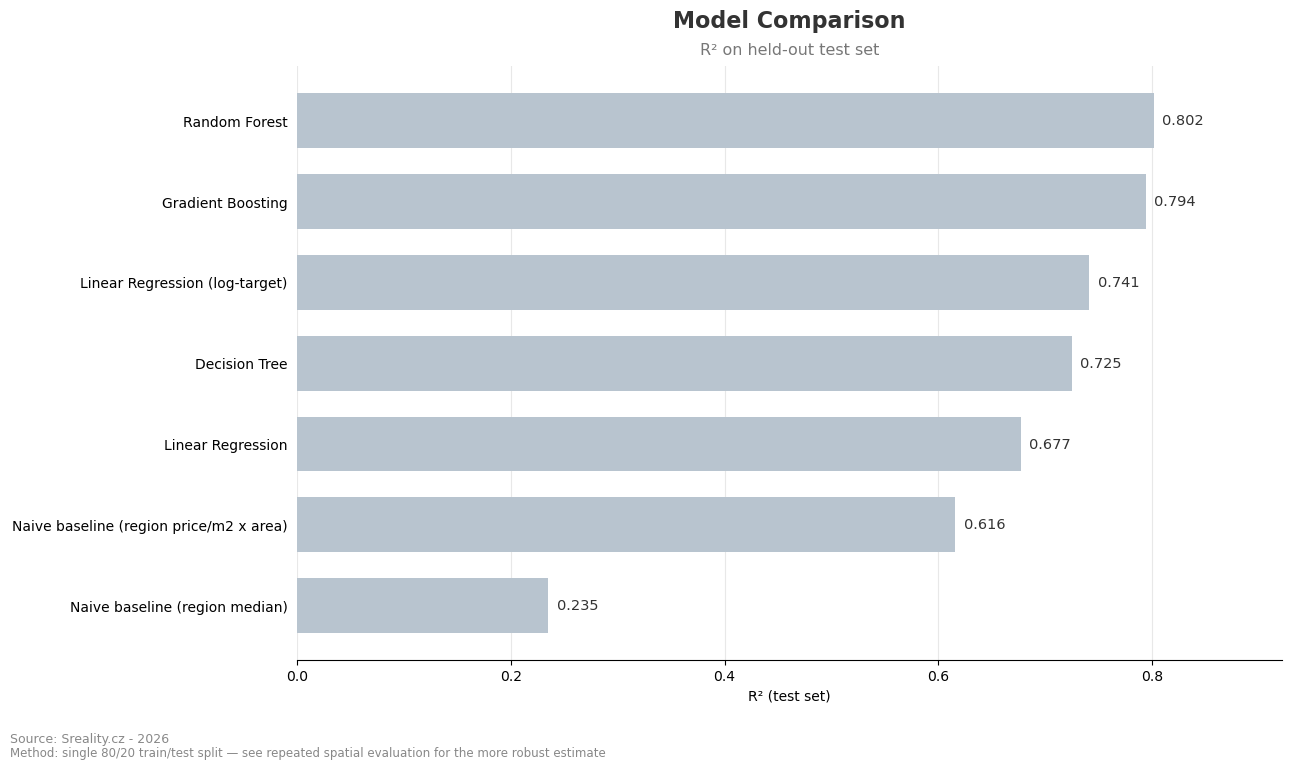

In [38]:
order = results_df['R2'].sort_values().index
data = results_df.loc[order, 'R2']

# Main colors
COLOR_DEFAULT = '#B8C4CF'
COLOR_TEXT = '#333333'
COLOR_SECONDARY = '#777777'
COLOR_GRID = '#E8E8E8'

plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.barh(order, data.values, height=0.68, color=COLOR_DEFAULT)

for bar, val in zip(bars, data.values):
    ax.text(val + data.max()*0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=10.5, color=COLOR_TEXT)

ax.set_axisbelow(True)
ax.grid(axis='x', color=COLOR_GRID, linewidth=0.8, linestyle='-')
ax.set_title('Model Comparison', fontsize=16, fontweight='bold', color=COLOR_TEXT, loc='center', pad=28)
subtitle = 'R² on held-out test set'
ax.text(0.5, 1.015, subtitle, transform=ax.transAxes, fontsize=11.5, color=COLOR_SECONDARY, ha='center', va='bottom')

ax.set_xlabel('R² (test set)')
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False, labelsize=10)
ax.set_xlim(0, data.max() * 1.15)

fig.text(0.01, 0.025, 'Source: Sreality.cz - 2026', fontsize=9, color='#888888')
fig.text(0.01, 0.008, 'Method: single 80/20 train/test split — see repeated spatial evaluation for the more robust estimate', fontsize=8.5, color='#888888')

plt.tight_layout(rect=[0, 0.055, 1, 0.96])
plt.show()

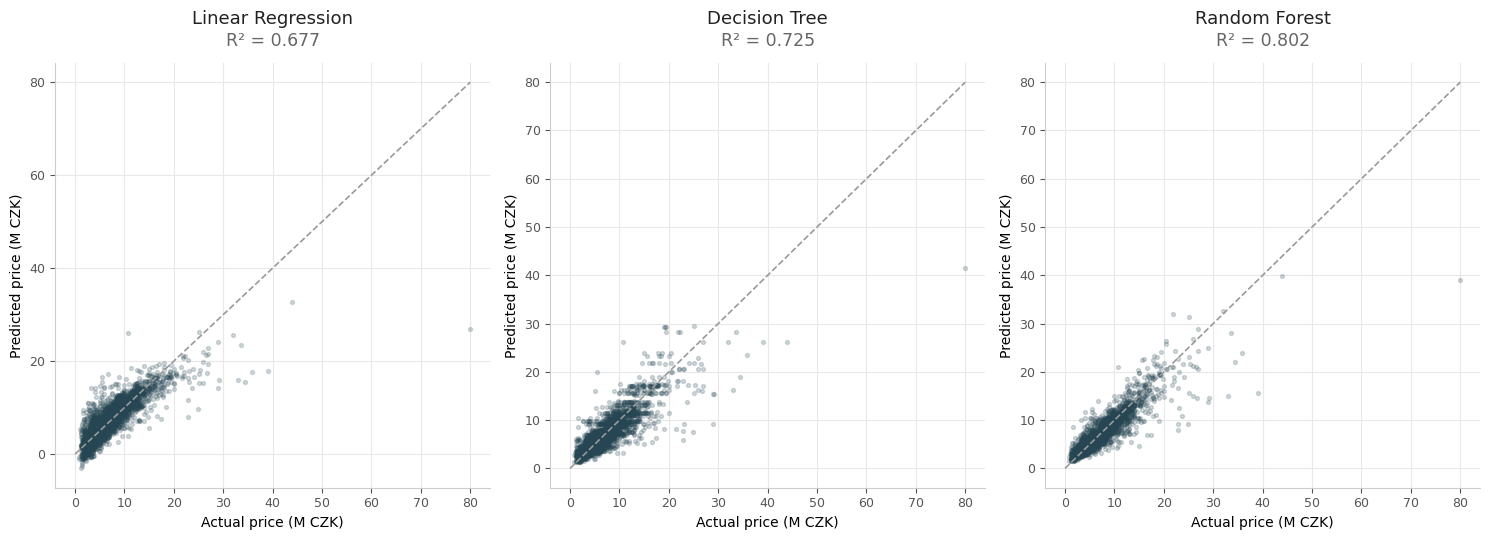

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

for ax, name in zip(axes, ['Linear Regression', 'Decision Tree', 'Random Forest']):
    y_pred = predictions[name]
    r2 = r2_score(y_test, y_pred)

    ax.scatter(y_test / 1e6, y_pred / 1e6, alpha=0.2, s=8, color='#264653')
    lims = [0, max(y_test.max(), y_pred.max()) / 1e6]
    ax.plot(lims, lims, '--', color='#999', linewidth=1.2)

    ax.set_title(name, fontsize=13, loc='center', color='#222', pad=28)
    ax.text(0.5, 1.04, f'R² = {r2:.3f}', transform=ax.transAxes,
             fontsize=12.5, color='#666', ha='center')

    ax.set_xlabel('Actual price (M CZK)')
    ax.set_ylabel('Predicted price (M CZK)')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(colors='#555555', labelsize=9)
    ax.grid(color='#e8e8e8', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Best model by test R²: Random Forest


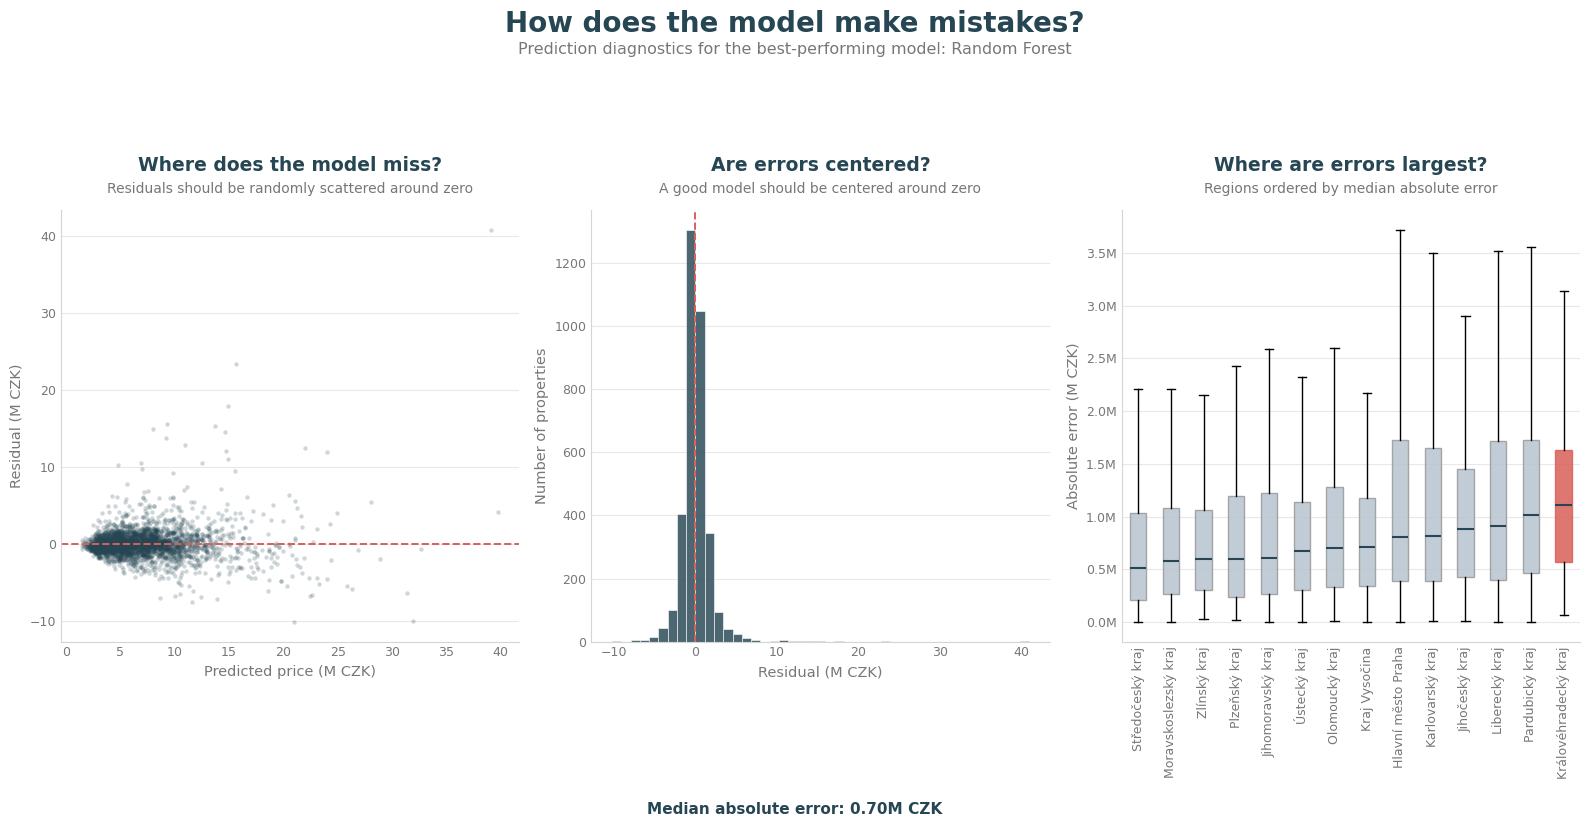

In [40]:
best_name = results_df['R2'].idxmax()
y_pred_best = predictions[best_name]
residuals = y_test - y_pred_best
print(f'Best model by test R²: {best_name}')

COLOR_MAIN = '#264653'
COLOR_ACCENT = '#D95F59'
COLOR_MUTED = '#B8C4CF'

COLOR_TEXT = '#264653'
COLOR_SECONDARY = '#777777'
COLOR_GRID = '#E8E8E8'
COLOR_ZERO = '#888888'

plt.rcParams['font.family'] = 'DejaVu Sans'
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
fig.patch.set_facecolor('white')

# Residuals vs fitted

ax = axes[0]
ax.scatter(y_pred_best / 1e6, residuals / 1e6, alpha=0.22, s=10, color=COLOR_MAIN, linewidths=0)
ax.axhline(0, color=COLOR_ACCENT, linestyle='--', linewidth=1.4)
ax.set_xlabel('Predicted price (M CZK)', fontsize=10.5, color=COLOR_SECONDARY)
ax.set_ylabel('Residual (M CZK)', fontsize=10.5, color=COLOR_SECONDARY)
ax.set_title('Where does the model miss?', fontsize=13.5, fontweight='bold', loc='center', color=COLOR_TEXT, pad=28)
ax.text(0.5, 1.04, 'Residuals should be randomly scattered around zero', transform=ax.transAxes, fontsize=10, color=COLOR_SECONDARY, ha='center')

# 5. Residual distribution

ax = axes[1]
ax.hist(residuals / 1e6, bins=45, color=COLOR_MAIN, alpha=0.82, edgecolor='white', linewidth=0.5)
ax.axvline(0, color=COLOR_ACCENT, linestyle='--', linewidth=1.4)
ax.set_xlabel('Residual (M CZK)', fontsize=10.5, color=COLOR_SECONDARY)
ax.set_ylabel('Number of properties', fontsize=10.5, color=COLOR_SECONDARY)
ax.set_title('Are errors centered?', fontsize=13.5, fontweight='bold', loc='center', color=COLOR_TEXT, pad=28)
ax.text(0.5, 1.04, 'A good model should be centered around zero', transform=ax.transAxes, fontsize=10, color=COLOR_SECONDARY, ha='center')

# ABSOLUTE ERROR BY REGION

abs_resid_by_region = pd.DataFrame({'region': X_test['region'].values, 'abs_resid': np.abs(residuals)})
region_order = (abs_resid_by_region.groupby('region')['abs_resid'].median().sort_values().index)
grouped_data = [abs_resid_by_region.loc[abs_resid_by_region['region'] == region, 'abs_resid'].values for region in region_order]
ax = axes[2]
bp = ax.boxplot(grouped_data, tick_labels=region_order, patch_artist=True, showfliers=False)

for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(COLOR_MUTED)
    patch.set_edgecolor('#999999')
    patch.set_alpha(0.85)
    if i == len(region_order) - 1:
        patch.set_facecolor(COLOR_ACCENT)
        patch.set_edgecolor(COLOR_ACCENT)
for median in bp['medians']:
    median.set_color(COLOR_TEXT)
    median.set_linewidth(1.5)
ax.set_title('Where are errors largest?', fontsize=13.5, fontweight='bold', loc='center', color=COLOR_TEXT, pad=28)

ax.text(0.5, 1.04, 'Regions ordered by median absolute error', transform=ax.transAxes, fontsize=10, color=COLOR_SECONDARY, ha='center')
ax.set_ylabel('Absolute error (CZK)', fontsize=10.5, color=COLOR_SECONDARY)
ax.tick_params(axis='x', rotation=90)

# 7. Format Y-axis of boxplot

axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M'))
axes[2].set_ylabel('Absolute error (M CZK)', fontsize=10.5, color=COLOR_SECONDARY)


for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#D5D5D5')
    ax.spines['bottom'].set_color('#D5D5D5')
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(colors=COLOR_SECONDARY, labelsize=9, length=0)
    ax.grid(axis='y', color=COLOR_GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

fig.suptitle('How does the model make mistakes?', fontsize=20, fontweight='bold', color=COLOR_TEXT, y=1.02)
fig.text(0.5, 0.965, f'Prediction diagnostics for the best-performing model: {best_name}', ha='center', fontsize=11.5, color=COLOR_SECONDARY)

median_abs_error = np.median(np.abs(residuals))

fig.text(0.5, 0.015, f'Median absolute error: {median_abs_error / 1e6:.2f}M CZK', ha='center', fontsize=11, fontweight='bold', color=COLOR_TEXT)


plt.tight_layout(rect=[0, 0.04, 1, 0.91])
plt.show()

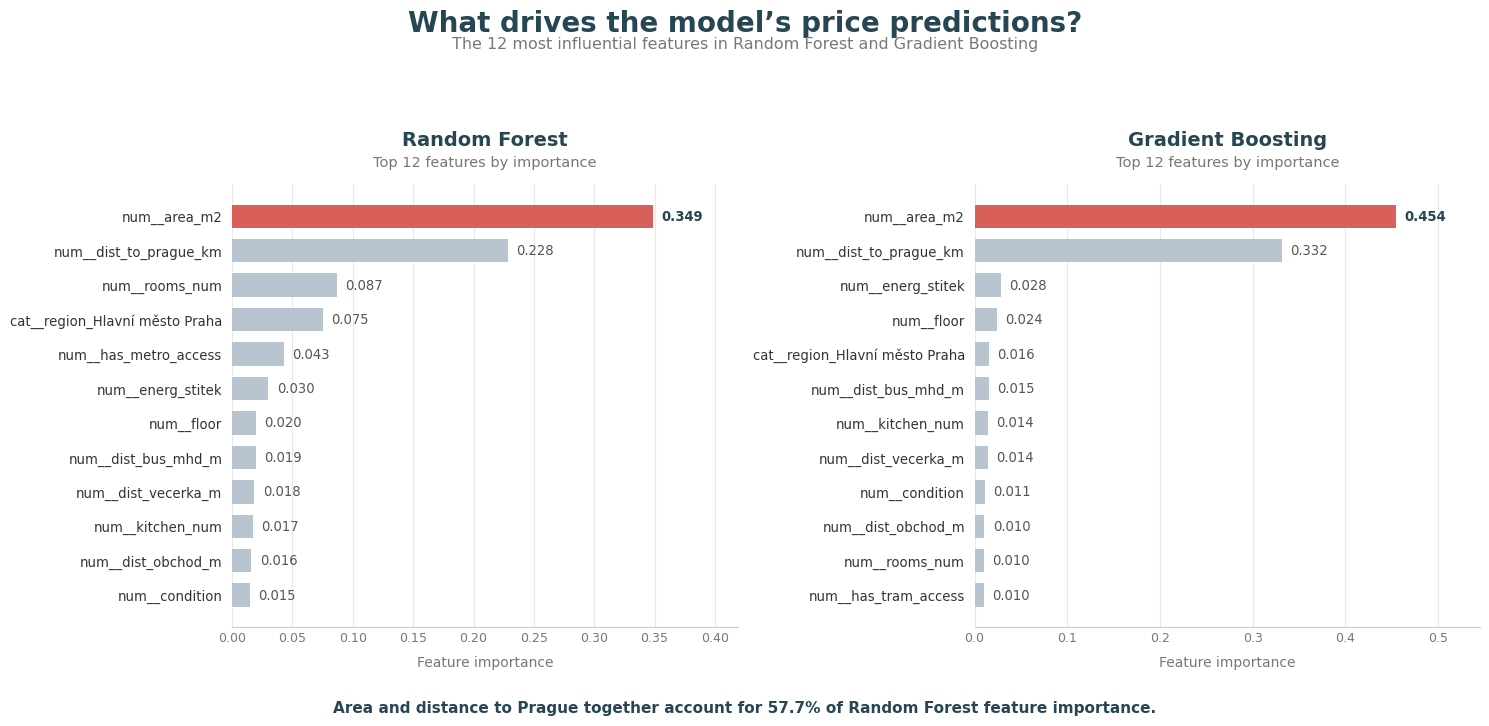

RF top 5:
num__area_m2                      0.349
num__dist_to_prague_km            0.228
num__rooms_num                    0.087
cat__region_Hlavní město Praha    0.075
num__has_metro_access             0.043
dtype: float64

GB top 5:
num__area_m2                      0.454
num__dist_to_prague_km            0.332
num__energ_stitek                 0.028
num__floor                        0.024
cat__region_Hlavní město Praha    0.016
dtype: float64

Combined share of area_m2 + dist_to_prague_km (RF): 57.7%


In [41]:
feat_names = preprocessor.get_feature_names_out()

rf_imp = (pd.Series(rf.named_steps['model'].feature_importances_, index=feat_names).sort_values(ascending=False))
gb_imp = (pd.Series(gb.named_steps['model'].feature_importances_, index=feat_names).sort_values(ascending=False))


COLOR_MAIN = '#264653'
COLOR_ACCENT = '#D95F59'
COLOR_MUTED = '#B8C4CF'

COLOR_TEXT = '#264653'
COLOR_SECONDARY = '#777777'
COLOR_GRID = '#E8E8E8'


plt.rcParams['font.family'] = 'DejaVu Sans'
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.patch.set_facecolor('white')

for ax, imp, name in zip(
    axes,
    [rf_imp, gb_imp],
    ['Random Forest', 'Gradient Boosting']
):
    top12 = imp.head(12)[::-1]  
    bar_colors = [COLOR_MUTED] * len(top12)
    bar_colors[-1] = COLOR_ACCENT
    bars = ax.barh(top12.index, top12.values, height=0.68, color=bar_colors)

    for bar, val in zip(
        bars,
        top12.values
    ):
        is_top = val == top12.max()
        ax.text(
            val + top12.max() * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center',
            fontsize=9.5,
            fontweight='bold' if is_top else 'normal',
            color=COLOR_TEXT if is_top else '#555555'
        )

    ax.set_title(name, fontsize=14, fontweight='bold', loc='center', color=COLOR_TEXT, pad=28)
    ax.text(0.5, 1.04, 'Top 12 features by importance', transform=ax.transAxes, fontsize=10.5, color=COLOR_SECONDARY, ha='center')
    ax.grid(axis='x', color=COLOR_GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    for spine in ['top', 'right', 'left']:ax.spines[spine].set_visible(False)

    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['bottom'].set_linewidth(0.8)

    ax.tick_params(axis='y', left=False, labelsize=9.5, colors='#333333')
    ax.tick_params(axis='x', colors=COLOR_SECONDARY, labelsize=9, length=0)
    ax.set_xlabel('Feature importance', fontsize=10, color=COLOR_SECONDARY, labelpad=8)

    ax.set_xlim(0, top12.max() * 1.20
)

fig.suptitle('What drives the model’s price predictions?', fontsize=20, fontweight='bold', color=COLOR_TEXT, y=1.02)
fig.text(0.5, 0.965, 'The 12 most influential features in Random Forest and Gradient Boosting', ha='center', fontsize=11.5, color=COLOR_SECONDARY)

combined_share = rf_imp[
    [
        'num__area_m2',
        'num__dist_to_prague_km'
    ]
].sum()


fig.text(
    0.5,
    0.015,
    f'Area and distance to Prague together account for '
    f'{combined_share:.1%} of Random Forest feature importance.',
    ha='center',
    fontsize=11,
    fontweight='bold',
    color=COLOR_TEXT
)

plt.tight_layout(rect=[0, 0.055, 1, 0.93])
plt.show()
print('RF top 5:')
print(rf_imp.head(5).round(3))
print('\nGB top 5:')
print(gb_imp.head(5).round(3))

print(
    f"\nCombined share of area_m2 + dist_to_prague_km (RF): "
    f"{combined_share:.1%}"
)

**`area_m2` and `dist_to_prague_km` together account for roughly 78-80% of both tree models' importance.** Everything else, construction type, condition, energy label, transit distances, ownership type, matters, but at a distant second order. This is a genuine, if slightly unglamorous, insight about the Czech apartment market: size and proximity to Prague explain almost all the price variance that these two ensemble models can find.

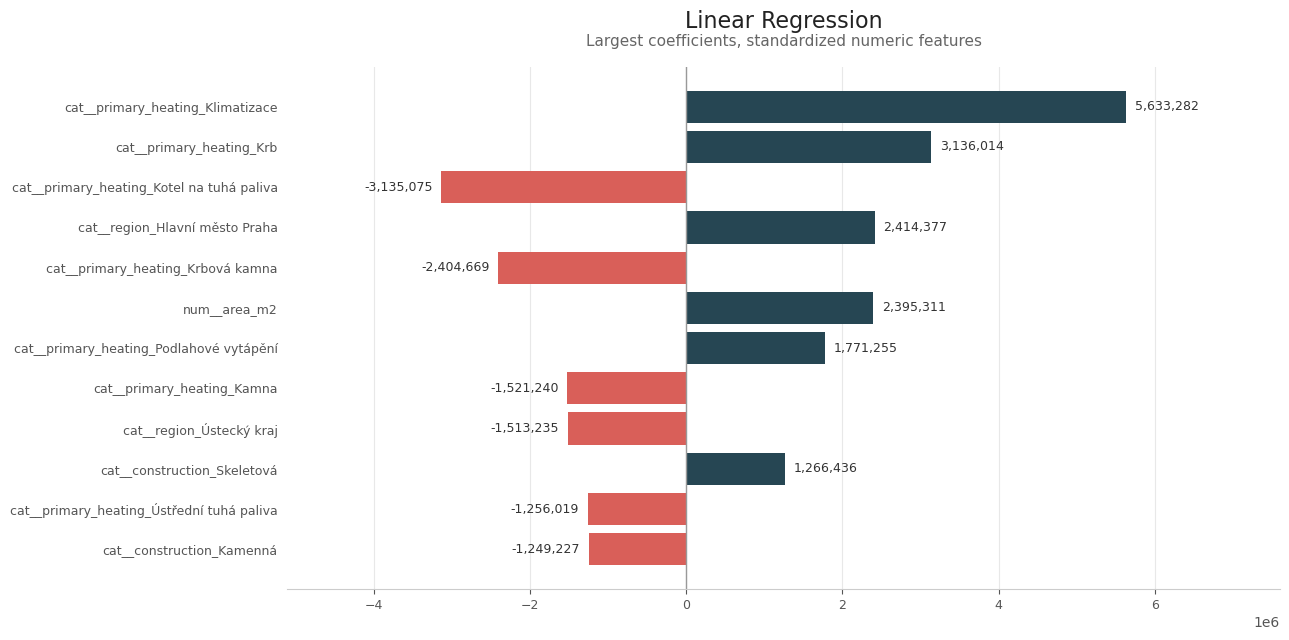

In [42]:
lr_coefs = pd.Series(lr.named_steps['model'].coef_, index=feat_names)
top_coefs = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=False).index).head(12)
plot_coefs = top_coefs[::-1]

fig, ax = plt.subplots(figsize=(13, 6.5))

colors = ['#D95F59' if c < 0 else '#264653' for c in plot_coefs]
bars = ax.barh(plot_coefs.index, plot_coefs.values, color=colors)

for bar, val in zip(bars, plot_coefs.values):
    offset = plot_coefs.abs().max() * 0.02
    x_pos = val + offset if val >= 0 else val - offset
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2, f'{val:,.0f}',
            va='center', ha=ha, fontsize=9, color='#333')

ax.axvline(0, color='#999', linewidth=1)

ax.set_title('Linear Regression', fontsize=16, loc='center', color='#222', pad=28)
ax.text(0.5, 1.04, 'Largest coefficients, standardized numeric features', transform=ax.transAxes,
         fontsize=11, color='#666', ha='center')

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(left=False, labelsize=9, colors='#555555')
ax.grid(axis='x', color='#e8e8e8', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

pad_frac = plot_coefs.abs().max() * 0.35
ax.set_xlim(plot_coefs.min() - pad_frac, plot_coefs.max() + pad_frac)

plt.tight_layout()
plt.show()

# sample sizes behind the biggest coefficients, to check for small-sample instability
for feat in top_coefs.index:
    if feat.startswith('cat_primary_heating_'):
        val = feat.replace('cat_primary_heating_', '')
        n = (df['primary_heating'] == val).sum()
        print(f'{feat}: coefficient={lr_coefs[feat]:,.0f}  n={n}')

Several of the largest Linear Regression coefficients belong to rare `primary_heating` categories with only 27-66 listings each (out of 17,738). A single category swinging price by several million CZK on the strength of a few dozen data points is a classic small-sample instability problem for linear models with many one-hot categories, not a reliable causal effect. The tree-based models are far more robust to this, since a rare category can only ever justify a small, heavily-regularized split rather than a large linear coefficient. This is a good reason to trust the Random Forest / Gradient Boosting importances over the raw Linear Regression coefficients for anything involving low-frequency categories.

## 8. Repeated Spatial evaluation (Primary reported metric)

A single 80/20 spatial split is still just one draw of the grid and `grid_id` cells are highly uneven (median 2 listings per cell, but the largest cells running into the hundreds, almost certainly dense new-build complexes). That unevenness means a single grouped split can carry real sampling variance in principle, so rather than trust the section 5/7 split as the headline number, this section reruns **every** model, both baselines, Linear Regression (raw and log-target) and the tuned Decision Tree/Random Forest/Gradient Boosting, across `N_REPEATS` independent 80/20 grouped draws of the full de-duplicated dataset and reports the mean +/- standard deviation as the primary metric.

**In this run, the section 5 split turned out to be reasonably representative.** The comparison below shows every model's single-split R² landing within about 2 standard deviations of its repeated mean (see the automatic flag in the next cell, none fire). The largest drifts belong to the simpler models, not the tuned ensembles: the region price/m² baseline (-0.054) and log-target Linear Regression (+0.047), both still well inside one repeated-eval standard deviation. Random Forest and Gradient Boosting, the models this section cares most about, are the *closest* of all to their repeated means (-0.007 and +0.002 respectively).

That doesn't make the repeated evaluation redundant, though, it's what lets us *know* the single split wasn't an outlier, rather than assume it. With cells this uneven, a bad draw remains possible on a rerun with a different `random_state` and the `_std` columns below are the honest way to see how much the estimate could plausibly move. Section 7's single-split table still exists and still backs the diagnostics that need one fixed holdout (residuals, feature importance, coefficients), but §8's repeated mean +/- std is the number to trust for "how good is this model, really."

Hyperparameters are **not** re-searched inside each repeat, they're fixed at whatever section 6's grouped-CV search already selected (`best_dt_params`, `best_rf_params`, `best_gb_params`). Re-tuning inside every repeat would multiply the compute cost for a benefit this dataset likely doesn't need, since location and size dominate regardless of the exact split; see section 9 for the honest nested-CV caveat this implies.

In [43]:
def fit_and_score_all(X_tr_full, y_tr_full, X_te_full, y_te_full, df_tr_slice):
    """Fit every model (2 baselines + 5 ML models) on one train/test draw and return
    {model_name: {R2, MAE, RMSE, MAPE}}. Reuses the hyperparameters already selected
    in section 6 (best_dt_params/best_rf_params/best_gb_params) rather than re-running
    the searches inside every repeat."""
    out = {}

    def score(name, y_true, y_pred):
        r2 = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        out[name] = dict(R2=r2, MAE=mae, RMSE=rmse, MAPE=mape)

    # baselines: region stats computed from this repeat's training fold only
    region_median_r = df_tr_slice.groupby('region')['price_czk'].median()
    score('Naive baseline (region median)', y_te_full,
          X_te_full['region'].map(region_median_r).fillna(y_tr_full.mean()).values)

    tr = df_tr_slice.copy()
    tr['price_per_m2'] = tr['price_czk'] / tr['area_m2']
    region_ppm2_r = tr.groupby('region')['price_per_m2'].median()
    overall_ppm2_r = tr['price_per_m2'].median()
    score('Naive baseline (region price/m2 x area)', y_te_full,
          (X_te_full['region'].map(region_ppm2_r).fillna(overall_ppm2_r) * X_te_full['area_m2']).values)

    # Linear Regression
    m = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
    m.fit(X_tr_full, y_tr_full)
    score('Linear Regression', y_te_full, m.predict(X_te_full))

    # Linear Regression (log-target)
    m = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
    y_tr_log = np.log1p(y_tr_full)
    m.fit(X_tr_full, y_tr_log)
    log_pred = m.predict(X_te_full)
    log_pred_clipped = np.clip(log_pred, y_tr_log.min(), y_tr_log.max())
    score('Linear Regression (log-target)', y_te_full, np.expm1(log_pred_clipped))

    # Decision Tree (section 6's tuned structure)
    m = Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(
        random_state=42, **best_dt_params))])
    m.fit(X_tr_full, y_tr_full)
    score('Decision Tree', y_te_full, m.predict(X_te_full))

    # Random Forest (section 6's tuned structure, full 300 trees)
    m = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1, **best_rf_params))])
    m.fit(X_tr_full, y_tr_full)
    score('Random Forest', y_te_full, m.predict(X_te_full))

    # Gradient Boosting (section 6's tuned structure, with early stopping)
    m = Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(
        n_estimators=300, random_state=42, validation_fraction=0.1,
        n_iter_no_change=10, tol=1e-4, **best_gb_params))])
    m.fit(X_tr_full, y_tr_full)
    score('Gradient Boosting', y_te_full, m.predict(X_te_full))

    return out

In [44]:
N_REPEATS = 15
# random_state=123 here is deliberately different from section 5's split (random_state=42), so this genuinely explores different draws rather than re-running the same one.
gss_repeated = GroupShuffleSplit(n_splits=N_REPEATS, test_size=0.2, random_state=123)

model_names = [
    'Naive baseline (region median)', 'Naive baseline (region price/m2 x area)',
    'Linear Regression', 'Linear Regression (log-target)',
    'Decision Tree', 'Random Forest', 'Gradient Boosting',
]
per_repeat_scores = {name: {'R2': [], 'MAE': [], 'RMSE': [], 'MAPE': []} for name in model_names}

X_full = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
X_full['vlastnictvi'] = X_full['vlastnictvi'].astype(str)
y_full = df['price_czk'].values
groups_full = df['grid_id'].values

for rep, (tr_idx, te_idx) in enumerate(gss_repeated.split(X_full, y_full, groups=groups_full), 1):
    X_tr_r, X_te_r = X_full.iloc[tr_idx], X_full.iloc[te_idx]
    y_tr_r, y_te_r = y_full[tr_idx], y_full[te_idx]
    df_tr_r = df.iloc[tr_idx]  # training fold only, for the baseline lookups, fresh each repeat

    scores = fit_and_score_all(X_tr_r, y_tr_r, X_te_r, y_te_r, df_tr_r)
    for name, metrics in scores.items():
        for k, v in metrics.items():
            per_repeat_scores[name][k].append(v)

    print(f'Repeat {rep:2d}/{N_REPEATS}   '
          f'RF R2={scores["Random Forest"]["R2"]:.3f}   GB R2={scores["Gradient Boosting"]["R2"]:.3f}   '
          f'(test cells fully held out from train)')

Repeat  1/15   RF R2=0.829   GB R2=0.818   (test cells fully held out from train)
Repeat  2/15   RF R2=0.833   GB R2=0.834   (test cells fully held out from train)
Repeat  3/15   RF R2=0.788   GB R2=0.771   (test cells fully held out from train)
Repeat  4/15   RF R2=0.748   GB R2=0.731   (test cells fully held out from train)
Repeat  5/15   RF R2=0.864   GB R2=0.863   (test cells fully held out from train)
Repeat  6/15   RF R2=0.828   GB R2=0.816   (test cells fully held out from train)
Repeat  7/15   RF R2=0.833   GB R2=0.835   (test cells fully held out from train)
Repeat  8/15   RF R2=0.782   GB R2=0.781   (test cells fully held out from train)
Repeat  9/15   RF R2=0.775   GB R2=0.775   (test cells fully held out from train)
Repeat 10/15   RF R2=0.807   GB R2=0.805   (test cells fully held out from train)
Repeat 11/15   RF R2=0.828   GB R2=0.820   (test cells fully held out from train)
Repeat 12/15   RF R2=0.793   GB R2=0.750   (test cells fully held out from train)
Repeat 13/15   R

In [45]:
summary_rows = {}
for name, metrics in per_repeat_scores.items():
    row = {}
    for k, v in metrics.items():
        row[f'{k}_mean'] = np.mean(v)
        row[f'{k}_std'] = np.std(v)
    summary_rows[name] = row

repeated_results_df = pd.DataFrame(summary_rows).T[
    ['R2_mean', 'R2_std', 'MAE_mean', 'MAE_std', 'RMSE_mean', 'RMSE_std', 'MAPE_mean', 'MAPE_std']
]

print(f'Repeated spatial evaluation ({N_REPEATS} independent 80/20 grouped draws), PRIMARY reported metric:\n')
print(repeated_results_df.round(3))

print()
print('Comparison: section 7 single-split R2 vs. this section\'s repeated-split mean R2')
for name in model_names:
    single_r2 = results.get(name, {}).get('R2', np.nan)
    rep_r2 = repeated_results_df.loc[name, 'R2_mean']
    rep_std = repeated_results_df.loc[name, 'R2_std']
    diff = single_r2 - rep_r2
    flag = '  <single split was NOT representative; trust the repeated mean' if abs(diff) > 2 * rep_std else ''
    print(f'  {name:42s} single={single_r2:.3f}   repeated_mean={rep_r2:.3f} (+/-{rep_std:.3f})   diff={diff:+.3f}{flag}')

repeated_results_df

Repeated spatial evaluation (15 independent 80/20 grouped draws), PRIMARY reported metric:

                                         R2_mean  R2_std     MAE_mean  \
Naive baseline (region median)             0.243   0.029  2697025.403   
Naive baseline (region price/m2 x area)    0.670   0.048  1914156.551   
Linear Regression                          0.651   0.030  1864009.115   
Linear Regression (log-target)             0.694   0.041  1612802.994   
Decision Tree                              0.740   0.038  1563131.829   
Random Forest                              0.805   0.033  1286088.401   
Gradient Boosting                          0.797   0.037  1298395.913   

                                            MAE_std    RMSE_mean    RMSE_std  \
Naive baseline (region median)           250606.933  4865855.766  646931.935   
Naive baseline (region price/m2 x area)   92797.619  3179703.436  238641.672   
Linear Regression                        119176.564  3299462.006  426170.345   
Lin

,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPE_mean,MAPE_std
Naive baseline (region median),0.243370,0.029212,2.697025e+06,250606.932798,4.865856e+06,646931.934650,37.189692,1.743411
Naive baseline (region price/m2 x area),0.669956,0.047892,1.914157e+06,92797.618618,3.179703e+06,238641.671638,30.439217,1.559962
Linear Regression,0.650758,0.030256,1.864009e+06,119176.563788,3.299462e+06,426170.344998,30.677410,1.796711
Linear Regression (log-target),0.694458,0.040906,1.612803e+06,141630.172830,3.072998e+06,346376.914081,22.973215,1.019822
Decision Tree,0.739853,0.037685,1.563132e+06,93102.209321,2.825107e+06,238825.240516,23.538517,0.903091
Random Forest,0.804713,0.033193,1.286088e+06,92094.069743,2.446095e+06,238120.676707,19.325750,0.849738
Gradient Boosting,0.797254,0.037161,1.298396e+06,86325.594542,2.488481e+06,232935.904905,19.369409,0.845793


**How to read this table:** the `_std` columns are the spread across `N_REPEATS` different 20%-holdout draws, i.e., how much this dataset's performance estimate genuinely wobbles depending on which neighborhoods happen to land in the test set. That's not a formal confidence interval, but it's a far more honest sense of uncertainty than a single number ever gives. Where a model's single-split result from section 7 falls more than ~2 standard deviations from its repeated mean here (flagged automatically above), treat the repeated mean as the number to trust and the single split as an unusually easy or hard draw rather than evidence the model itself changed.

One thing this does *not* fix: `grid_id`'s ~2km cell size is still the same judgment call flagged in section 4. Too fine and repeated draws start resembling a plain random split again (re-introducing leakage); too coarse and they start testing cross-region transfer instead of within-country generalization. Repeating the split many times reduces the *variance* of the estimate; it doesn't change what the underlying split is measuring.

## 9. Summary & Conclusions

**Model comparison:** see `repeated_results_df` computed in §8 for the primary R²/MAE/RMSE/MAPE figures (mean +/- std across many spatial holdouts), deliberately not retyped here, since a hardcoded copy is exactly what went stale the last time this notebook's features changed. The §7 `results_df` table still exists for the single-split diagnostics, but §8 is the number to trust for "how good is this model, really." If you need a static copy for a report, generate it from `repeated_results_df` right before exporting rather than hand-typing it.

**Key findings:**

1. **Location and size dominate.** `area_m2` and `dist_to_prague_km` alone account for the large majority of both ensemble models' feature importance. Everything else (construction, condition, energy label, transit access, ownership type) is real but second-order. Worth noting: tree impurity-based importance is known to somewhat favor high-cardinality/continuous features like these over one-hot categorical ones, so treat the exact split as directionally right rather than precise.
2. **Gradient Boosting and Random Forest are close**, both models' hyperparameters are selected via grouped 5-fold CV and their accuracy is compared via repeated spatial evaluation rather than one split, so the ranking reflects a fair, stable fight between tuned model families rather than an artifact of a lucky draw. Check `repeated_results_df` for which one currently edges out the other and by how much relative to its `_std`, if the gap is smaller than the noise, treat it as a toss-up.
3. **Log-transforming the target for Linear Regression barely changes R² but meaningfully cuts MAPE.** The raw-price model gets pulled around by a handful of ultra-expensive Prague listings; the log version is far more accurate for typical mid-market apartments, at a small cost in absolute-CZK accuracy on the luxury segment.
4. **Rare categorical levels destabilize Linear Regression coefficients.** Heating types with a few dozen listings can produce coefficients of several million CZK, an artifact of small samples, not a trustworthy causal estimate. Tree-based feature importances are more reliable here.
5. **Errors grow with price.** Residuals widen substantially for expensive properties; the model is proportionally consistent but absolute errors on multi-million-CZK Prague listings can still be a million+ CZK.
6. **`latitude`/`longitude` were dropped and this was an interpretability choice, not a VIF-mandated one.** The multicollinearity check found their VIF (with `dist_to_prague_km` in the mix) was well under 10, so they weren't actually causing severe instability. Dropping them cost a small amount of accuracy in exchange for collapsing location down to one interpretable "distance to Prague" axis instead of two raw coordinates; direction from Prague (not just radius) is lost in that trade. Worth revisiting if raw accuracy matters more than that interpretability for a given use case.
7. **`condition` and `energ_stitek` are encoded as ordinal numeric features**, matching the ordered integer scale established during cleaning (energy label A>G as 7>1, condition Špatný>Novostavba as 1>9), rather than one-hot categorical, so the linear model can use the ordering directly. `vlastnictvi` (ownership type) has no natural order and stays one-hot encoded. **Rows missing either field are dropped rather than imputed.** An earlier version filled missing energy label/condition with 0 (silently placing "not stated" below the worst real category), then a later version median-imputed with an explicit missing-flag instead. Both were guesses for core valuation fields where a guess isn't good enough; dropping those rows is the more defensible choice, at the cost of the listings themselves.
8. **`dist_tram_m`/`dist_metro_m` are dropped as columns; only `has_tram_access`/`has_metro_access` remain.** This missingness is structural, not random. Metro exists only in Prague and trams only in a handful of Czech cities, so dropping rows with missing values (as done for `energ_stitek`/`condition`) was considered and rejected: it would restrict the dataset to inner Prague only, losing well over 80-90% of listings. Median-filling the distance (an earlier version of this notebook) avoided that but made the flag and distance columns almost perfectly collinear (VIF ~47-48). Dropping the distance columns entirely resolves both problems: the binary flags carry the "transit available here" signal nationwide, without inventing a distance value or destroying the sample.
9. **`is_atypical_layout` no longer exists as a feature.** An earlier version kept "Atypický" listings with a flag and NaN'd-then-imputed room/kitchen counts; there's no honest room count for a non-standard layout, so these listings are dropped during cleaning instead.
10. **Near-duplicate listings are removed upfront and the train/test split is spatially grouped.** Earlier steps removed near-duplicate listings (same lat/lon/area/price) from the full dataset and split on `grid_id` via `GroupShuffleSplit` rather than on individual rows, so no grid cell is divided between train and test.
11. **Decision Tree, Random Forest and Gradient Boosting are tuned and every CV score is grouped by `grid_id`.** An earlier version fixed all three models' hyperparameters by hand and used plain (non-grouped) K-fold CV for Linear Regression and Decision Tree, both gaps are closed here.
12. **A single spatial split isn't automatically reliable enough to be the headline number, even when it happens to check out.** `grid_id` cells are highly uneven (median 2 listings, largest cells in the hundreds), so a single 80/20 grouped draw carries real sampling variance in principle.

**Limitations, stated plainly:**

- ~38% of listings have no `heating` value at all; these were bucketed as "not stated" rather than imputed with a guessed type.
- The exact-duplicate check runs against the full dataset before any split, catching same-lat/lon/area/price rows. Looser near-duplicates (e.g., a small price change on a re-listing, or a tiny GPS jitter between two scrapes of the same unit) aren't caught by this rule and could still land on both sides of a split. Worth tightening (e.g., a small-radius + similar-area fuzzy match) before treating this as production-ready.
- Feature importance here is impurity-based (MDI); permutation importance or SHAP would be a more robust basis for strong claims about which features matter most.
- Random Forest's search fixes `n_estimators=150` while tuning depth/leaf/features, then refits the winning structure with 300 trees for the final model; Gradient Boosting's search relies on early stopping (`n_iter_no_change`/`validation_fraction`) rather than searching `n_estimators` directly. Both are deliberate cost-saving choices for a 17k-row dataset under grouped 5-fold CV, not a full unconstrained search.
- `grid_id`'s ~2km cell size is a judgment call that both the split and the repeated evaluation inherit. Finer cells drift back toward a plain random split (and its leakage); coarser cells start testing cross-region transfer rather than within-country generalization to unseen neighborhoods.

**Bottom line:** a Random Forest or Gradient Boosting model explains most of the price variance in this dataset, driven overwhelmingly by size and distance to Prague, a result that matches well-known intuitions about the Czech real estate market, which is reassuring for the model's face validity rather than a coincidence. The number to actually quote, though, is repeated spatial evaluation, not a single train/test split.